<a href="https://colab.research.google.com/github/chaeni-dev/telco-churn-feature-engineering/blob/main/%EA%B3%BC%EC%A0%9C3_2126304_%EA%B9%80%EC%B1%84%EC%9D%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [과제3] Feature Engineering Pipeline 구현 및 성능 비교 실험

## STEP 00. 데이터셋 다운로드 및 로드

본 과제에서는 Kaggle의 Telco Customer Churn Dataset을 사용한다.

- 데이터셋명: Telco Customer Churn
- 출처: Kaggle
- 목적: 고객 이탈 여부 예측
- 문제 유형: 이진 분류 Classification
- 타겟 변수: Churn
- 특징:
  - 범주형 변수가 많음
  - 수치형 변수 포함
  - 고객 이탈 예측 문제에 적합
  - 결측치 처리, 인코딩, 스케일링, 파생변수 생성 실험에 적합

In [1]:
!pip install -q kaggle

In [2]:
from getpass import getpass
import os
import json

# Kaggle username 입력
kaggle_username = input("Kaggle username을 입력하세요: ")

# Kaggle API key 입력
kaggle_key = getpass("Kaggle API key를 입력하세요: ")

# Kaggle 인증 폴더 생성
os.makedirs("/root/.kaggle", exist_ok=True)

# kaggle.json 파일 생성
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({
        "username": kaggle_username,
        "key": kaggle_key
    }, f)

# 권한 설정
os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API 인증 파일 생성 완료")

Kaggle username을 입력하세요: chaeni-dev
Kaggle API key를 입력하세요: ··········
Kaggle API 인증 파일 생성 완료


In [3]:
!kaggle datasets list -s "telco customer churn"

ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
blastchar/telco-customer-churn                                   Telco Customer Churn                                    175758  2018-02-23 18:20:00.210000         558016       3702  0.88235295       
abdallahwagih/telco-customer-churn                               Telco Customer Churn                                   1314646  2024-10-11 05:27:55.330000           4401         72  0.88235295       
alfathterry/telco-customer-churn-11-1-3                          Telco customer churn (11.1.3+)                          525781  2024-05-08 20:46:56.010000           6274         74  1            

In [4]:
!kaggle datasets download -d blastchar/telco-customer-churn

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 55.1MB/s]



In [5]:
import os

os.listdir()

['.config', 'telco-customer-churn.zip', 'sample_data']

In [6]:
import zipfile
import os

zip_path = "telco-customer-churn.zip"
extract_path = "./telco_customer_churn"

# 압축 해제 폴더 생성
os.makedirs(extract_path, exist_ok=True)

# zip 파일 압축 해제
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("압축 해제 완료")

압축 해제 완료


In [7]:
os.listdir(extract_path)

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [8]:
import pandas as pd

file_path = "./telco_customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
print("데이터 shape:", df.shape)

print("\n컬럼 목록:")
print(df.columns.tolist())

print("\n데이터 정보:")
df.info()

데이터 shape: (7043, 21)

컬럼 목록:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSe

In [10]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [11]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


# STEP 01. 데이터 준비

본 단계에서는 Telco Customer Churn Dataset을 불러오고, 데이터의 기본 구조를 확인한다.

주요 수행 내용은 다음과 같다.

1. 데이터셋 소개
2. 컬럼 설명 표 작성
3. 데이터 크기 및 기본 정보 확인
4. 타겟 변수 정의
5. 수치형 변수와 범주형 변수 확인
6. 지도학습 문제로 적합한지 확인

## 1. 데이터셋 소개

본 과제에서는 Kaggle의 **Telco Customer Churn Dataset**을 사용한다.

이 데이터셋은 통신사 고객의 서비스 이용 정보, 계약 정보, 결제 정보, 인구통계 정보를 바탕으로 고객이 이탈했는지 여부를 예측하는 데이터셋이다.

- 데이터셋명: Telco Customer Churn Dataset
- 출처: Kaggle
- 문제 유형: 이진 분류 Binary Classification
- 예측 목표: 고객 이탈 여부 예측
- 타겟 변수: Churn
- 데이터 샘플 수: 약 7,000개
- 주요 변수 유형:
  - 범주형 변수: gender, Partner, Contract, PaymentMethod 등
  - 수치형 변수: tenure, MonthlyCharges, TotalCharges 등

본 데이터셋은 범주형 변수가 많고, 일부 수치형 변수의 타입 변환 및 결측치 처리가 필요하므로 Feature Engineering 실습에 적합하다.

In [12]:
# 데이터 상위 5개 행 확인
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
# 데이터 크기 확인
print("데이터 shape:", df.shape)
print("행 개수:", df.shape[0])
print("컬럼 개수:", df.shape[1])

데이터 shape: (7043, 21)
행 개수: 7043
컬럼 개수: 21


In [14]:
# 데이터 기본 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
# 컬럼 목록 확인
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

## 2. 컬럼 설명

Telco Customer Churn Dataset은 고객의 기본 정보, 서비스 이용 정보, 계약 및 결제 정보, 이탈 여부로 구성되어 있다.

아래 표는 주요 컬럼의 의미를 정리한 것이다.

In [16]:
# 컬럼 설명 표 작성
column_description = pd.DataFrame({
    "컬럼명": [
        "customerID",
        "gender",
        "SeniorCitizen",
        "Partner",
        "Dependents",
        "tenure",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod",
        "MonthlyCharges",
        "TotalCharges",
        "Churn"
    ],
    "설명": [
        "고객 고유 ID",
        "고객 성별",
        "고령 고객 여부",
        "배우자 유무",
        "부양가족 유무",
        "서비스 이용 기간",
        "전화 서비스 이용 여부",
        "복수 회선 사용 여부",
        "인터넷 서비스 유형",
        "온라인 보안 서비스 이용 여부",
        "온라인 백업 서비스 이용 여부",
        "기기 보호 서비스 이용 여부",
        "기술 지원 서비스 이용 여부",
        "TV 스트리밍 서비스 이용 여부",
        "영화 스트리밍 서비스 이용 여부",
        "계약 유형",
        "전자 청구서 사용 여부",
        "결제 방식",
        "월별 청구 금액",
        "총 청구 금액",
        "고객 이탈 여부"
    ],
    "변수 유형": [
        "식별자",
        "범주형",
        "범주형",
        "범주형",
        "범주형",
        "수치형",
        "범주형",
        "범주형",
        "범주형",
        "범주형",
        "범주형",
        "범주형",
        "범주형",
        "범주형",
        "범주형",
        "범주형",
        "범주형",
        "범주형",
        "수치형",
        "수치형",
        "타겟"
    ]
})

column_description

,컬럼명,설명,변수 유형
0,customerID,고객 고유 ID,식별자
1,gender,고객 성별,범주형
2,SeniorCitizen,고령 고객 여부,범주형
3,Partner,배우자 유무,범주형
4,Dependents,부양가족 유무,범주형
5,tenure,서비스 이용 기간,수치형
6,PhoneService,전화 서비스 이용 여부,범주형
7,MultipleLines,복수 회선 사용 여부,범주형
8,InternetService,인터넷 서비스 유형,범주형
9,OnlineSecurity,온라인 보안 서비스 이용 여부,범주형


In [17]:
# 타겟 변수 정의
target = "Churn"

print("타겟 변수:", target)
print("\n타겟 변수 값 분포:")
print(df[target].value_counts())

타겟 변수: Churn

타겟 변수 값 분포:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [18]:
# 타겟 변수 비율 확인
target_ratio = df[target].value_counts(normalize=True) * 100

print("타겟 변수 비율:")
print(target_ratio)

타겟 변수 비율:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [19]:
# 수치형 변수와 범주형 변수 분리
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("수치형 변수:")
print(numeric_features)

print("\n범주형 변수:")
print(categorical_features)

수치형 변수:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

범주형 변수:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [20]:
# TotalCharges 컬럼의 데이터 타입 확인
print("TotalCharges 데이터 타입:", df["TotalCharges"].dtype)

# TotalCharges의 일부 값 확인
df["TotalCharges"].head(10)

TotalCharges 데이터 타입: object


,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
5,820.5
6,1949.4
7,301.9
8,3046.05
9,3487.95


In [21]:
# TotalCharges는 숫자형 변수이지만 object 타입으로 저장되어 있으므로 숫자형으로 변환
# 변환할 수 없는 값은 NaN으로 처리
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("TotalCharges 변환 후 데이터 타입:", df["TotalCharges"].dtype)
print("TotalCharges 결측치 개수:", df["TotalCharges"].isnull().sum())

TotalCharges 변환 후 데이터 타입: float64
TotalCharges 결측치 개수: 11


In [22]:
# customerID와 Churn은 모델 입력 변수에서 제외할 예정
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("수치형 변수:")
print(numeric_features)

print("\n범주형 변수:")
print(categorical_features)

수치형 변수:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

범주형 변수:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [23]:
# 모델 입력 변수 X와 타겟 변수 y 정의
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [24]:
# 타겟 변수 Churn을 숫자형으로 변환
# No = 0, Yes = 1
y_encoded = y.map({
    "No": 0,
    "Yes": 1
})

print(y_encoded.value_counts())
print("\n타겟 인코딩 결과:")
print(pd.DataFrame({
    "원본 Churn": y.head(),
    "인코딩 Churn": y_encoded.head()
}))

Churn
0    5174
1    1869
Name: count, dtype: int64

타겟 인코딩 결과:
  원본 Churn  인코딩 Churn
0       No          0
1       No          0
2      Yes          1
3       No          0
4      Yes          1


In [25]:
print("지도학습 데이터셋 조건 확인")
print("- 입력 변수 X 존재:", X.shape)
print("- 타겟 변수 y 존재:", y_encoded.shape)
print("- 샘플 수 500개 이상 여부:", X.shape[0] >= 500)
print("- 수치형 변수 포함 여부:", len(numeric_features) > 0)
print("- 범주형 변수 포함 여부:", len(categorical_features) > 0)

지도학습 데이터셋 조건 확인
- 입력 변수 X 존재: (7043, 19)
- 타겟 변수 y 존재: (7043,)
- 샘플 수 500개 이상 여부: True
- 수치형 변수 포함 여부: True
- 범주형 변수 포함 여부: True


## STEP 01 정리

Telco Customer Churn Dataset을 로드한 결과, 데이터는 총 7,043개의 행과 21개의 컬럼으로 구성되어 있었다.

본 데이터셋의 타겟 변수는 `Churn`이며, 고객이 이탈한 경우 `Yes`, 이탈하지 않은 경우 `No`로 표시된다. 머신러닝 모델 학습을 위해 타겟 변수는 `No = 0`, `Yes = 1`로 인코딩하였다.

입력 변수에는 수치형 변수와 범주형 변수가 모두 포함되어 있어, 본 과제의 필수 조건인 수치형 + 범주형 변수 포함 조건을 만족한다. 또한 데이터 샘플 수가 500개 이상이므로 과제 조건을 충족한다.

`customerID`는 고객 식별자이므로 모델 학습에는 사용하지 않기로 하였다. `TotalCharges` 컬럼은 총 청구 금액을 의미하는 수치형 변수이지만, 원본 데이터에서는 object 타입으로 저장되어 있어 숫자형으로 변환하였다. 변환 과정에서 일부 값이 결측치로 처리되었으며, 이는 이후 결측치 처리 비교 실험에서 다룰 예정이다.

# STEP 02. 탐색적 데이터 분석 EDA

본 단계에서는 Telco Customer Churn Dataset의 데이터 품질과 변수 특성을 파악하기 위해 탐색적 데이터 분석을 수행한다.

필수 분석 항목은 다음과 같다.

1. 결측치 비율 분석
2. 이상치 탐색
3. 변수 분포 시각화
4. 상관관계 분석
5. 타겟 변수 분포 확인

필수 시각화 항목은 다음과 같다.

- Histogram
- Boxplot
- Heatmap
- Countplot 또는 Barplot

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 시각화 기본 설정
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

sns.set(style="whitegrid")

In [27]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2-1. 결측치 비율 분석

각 컬럼별 결측치 개수와 결측치 비율을 확인한다.  
특히 `TotalCharges`는 숫자형 변환 과정에서 일부 값이 결측치로 처리될 수 있으므로 확인이 필요하다.

In [28]:
# 컬럼별 결측치 개수와 비율 계산
missing_info = pd.DataFrame({
    "결측치 개수": df.isnull().sum(),
    "결측치 비율(%)": df.isnull().mean() * 100
})

# 결측치가 많은 순서로 정렬
missing_info = missing_info.sort_values(by="결측치 개수", ascending=False)

missing_info

,결측치 개수,결측치 비율(%)
TotalCharges,11,0.156183
gender,0,0.000000
SeniorCitizen,0,0.000000
Partner,0,0.000000
customerID,0,0.000000
Dependents,0,0.000000
tenure,0,0.000000
MultipleLines,0,0.000000
PhoneService,0,0.000000
OnlineSecurity,0,0.000000


In [29]:
missing_info[missing_info["결측치 개수"] > 0]

,결측치 개수,결측치 비율(%)
TotalCharges,11,0.156183


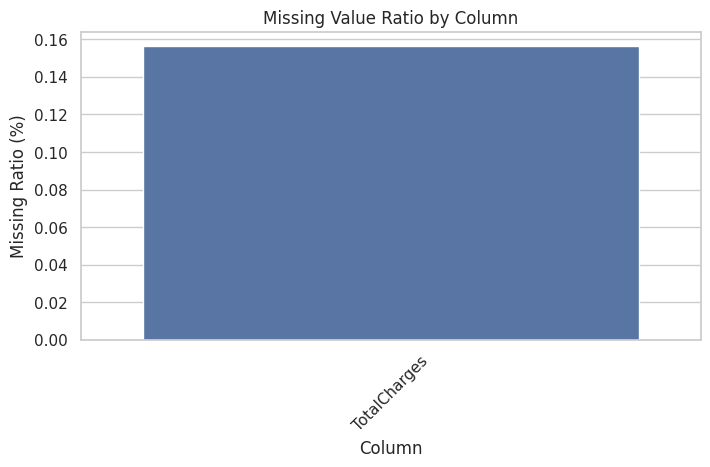

In [31]:
# 결측치가 있는 컬럼만 시각화
missing_only = missing_info[missing_info["결측치 개수"] > 0]

if len(missing_only) > 0:
    plt.figure(figsize=(8, 4))
    sns.barplot(x=missing_only.index, y=missing_only["결측치 비율(%)"])
    plt.title("Missing Value Ratio by Column")
    plt.xlabel("Column")
    plt.ylabel("Missing Ratio (%)")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("결측치가 있는 컬럼이 없습니다.")

### 결측치 분석 결과

`TotalCharges` 컬럼에서 결측치가 확인되었다.  
이는 원본 데이터에서 공백 문자열로 저장된 값이 숫자형으로 변환되는 과정에서 NaN으로 처리되었기 때문이다.

전체 데이터 수에 비해 결측치 비율은 매우 낮은 편이지만, 머신러닝 모델 학습을 위해서는 결측치 처리가 필요하다.  
따라서 이후 Feature Engineering 단계에서 Mean, Median, Most Frequent 등의 결측치 처리 전략을 비교한다.

## 2-2. 타겟 변수 분포 확인

타겟 변수 `Churn`의 클래스 분포를 확인하여 데이터 불균형 여부를 파악한다.

In [32]:
# 타겟 변수 분포 확인
churn_count = df["Churn"].value_counts()
churn_ratio = df["Churn"].value_counts(normalize=True) * 100

print("Churn 개수:")
print(churn_count)

print("\nChurn 비율(%):")
print(churn_ratio)

Churn 개수:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn 비율(%):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


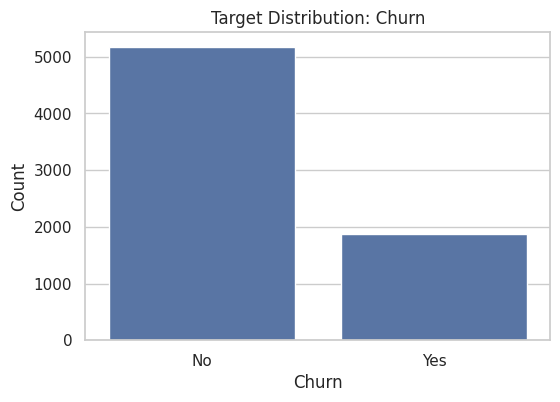

In [33]:
# Countplot으로 타겟 변수 분포 시각화
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Target Distribution: Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

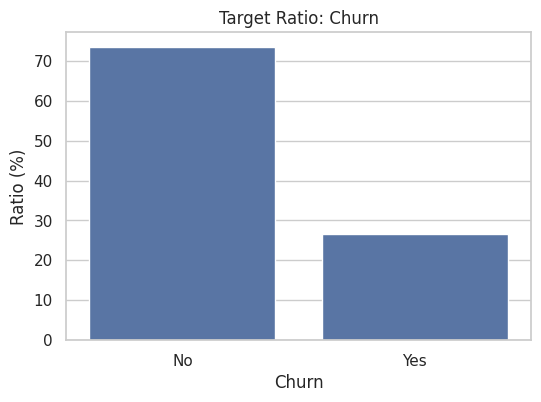

In [34]:
# 비율 기반 barplot
plt.figure(figsize=(6, 4))
sns.barplot(x=churn_ratio.index, y=churn_ratio.values)
plt.title("Target Ratio: Churn")
plt.xlabel("Churn")
plt.ylabel("Ratio (%)")
plt.show()

### 타겟 변수 분포 분석 결과

타겟 변수 `Churn`의 분포를 확인한 결과, 이탈하지 않은 고객 `No`가 이탈 고객 `Yes`보다 더 많은 것으로 나타났다.

일반적으로 `No` 클래스가 약 70% 이상, `Yes` 클래스가 약 20~30% 수준을 차지하므로 데이터는 다소 불균형한 이진 분류 문제라고 볼 수 있다.

따라서 단순 Accuracy만으로 모델을 평가하면 이탈 고객 예측 성능을 충분히 반영하지 못할 수 있다. 이후 모델 평가 단계에서는 Accuracy뿐만 아니라 Precision, Recall, F1-score, ROC-AUC를 함께 확인한다.

## 2-3. 수치형 변수 분포 시각화

수치형 변수인 `tenure`, `MonthlyCharges`, `TotalCharges`의 분포를 Histogram으로 확인한다.

In [35]:
# 분석에 사용할 수치형 변수 지정
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


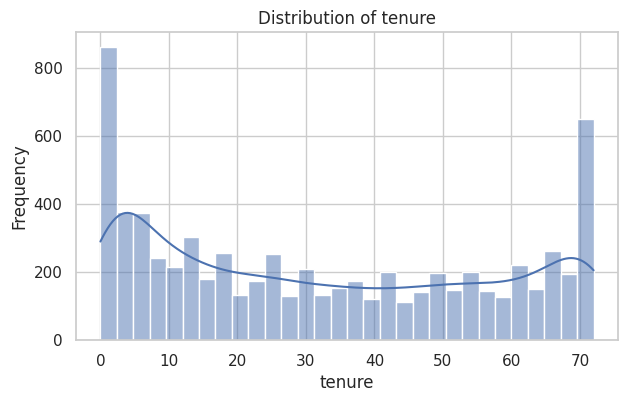

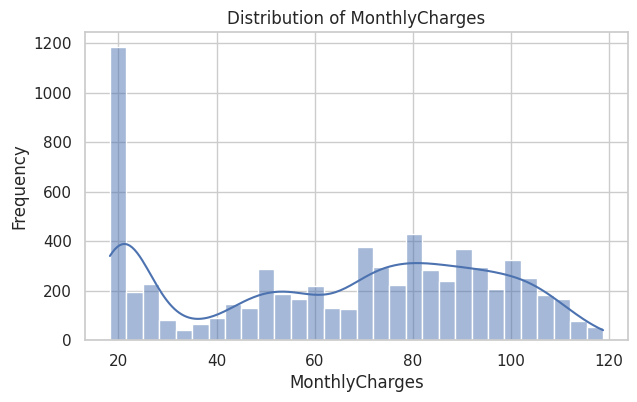

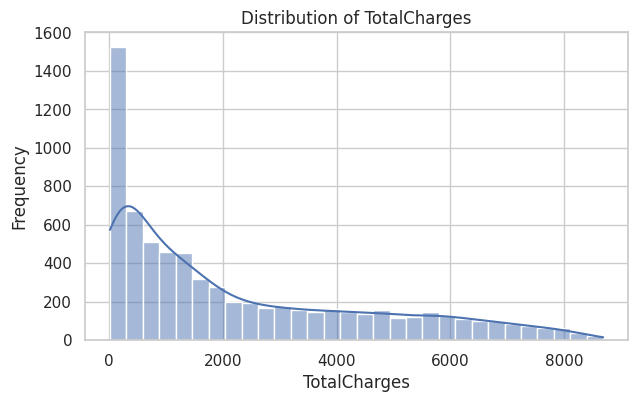

In [36]:
# 수치형 변수 Histogram 시각화
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### 수치형 변수 분포 분석 결과

`tenure`는 고객의 서비스 이용 기간을 의미하며, 짧은 이용 기간과 긴 이용 기간에 고객이 많이 분포하는 경향을 보인다.

`MonthlyCharges`는 월 청구 금액으로, 특정 구간에 고객이 많이 몰려 있으며 서비스 조합에 따라 요금 차이가 발생하는 것으로 보인다.

`TotalCharges`는 총 청구 금액으로, 이용 기간과 월 청구 금액의 영향을 함께 받기 때문에 오른쪽으로 긴 꼬리를 갖는 분포를 보일 수 있다.

## 2-4. 이상치 탐색

수치형 변수에 대해 Boxplot을 그려 이상치 존재 여부를 확인한다.  
또한 IQR 방법을 사용하여 각 수치형 변수의 이상치 개수를 계산한다.

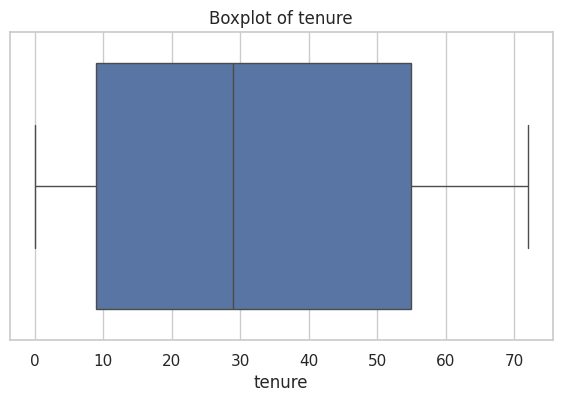

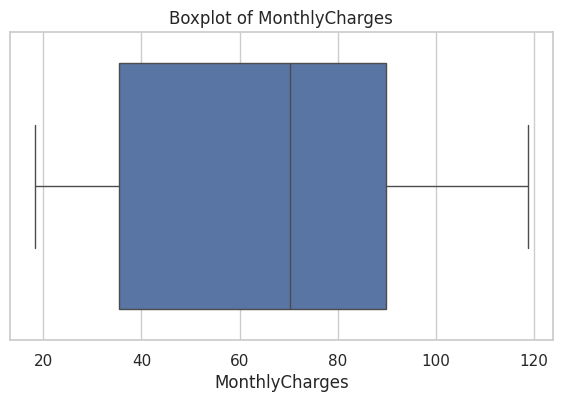

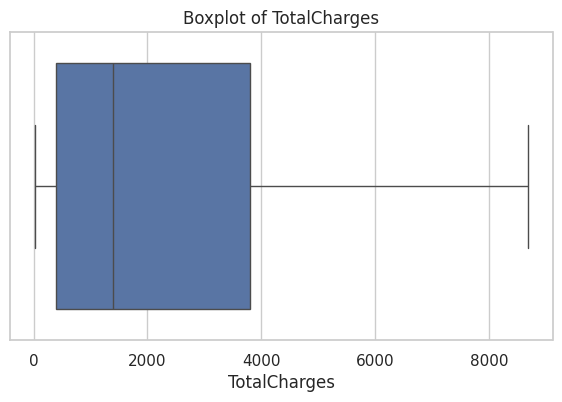

In [37]:
# 수치형 변수 Boxplot 시각화
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [38]:
# IQR 기반 이상치 개수 계산 함수
def count_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return {
        "변수명": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "하한값": lower_bound,
        "상한값": upper_bound,
        "이상치 개수": outliers.shape[0],
        "이상치 비율(%)": outliers.shape[0] / data[column].notnull().sum() * 100
    }

outlier_summary = pd.DataFrame([
    count_outliers_iqr(df, col) for col in numeric_cols
])

outlier_summary

,변수명,Q1,Q3,IQR,하한값,상한값,이상치 개수,이상치 비율(%)
0,tenure,9.00,55.0000,46.0000,-60.00000,124.00000,0,0.0
1,MonthlyCharges,35.50,89.8500,54.3500,-46.02500,171.37500,0,0.0
2,TotalCharges,401.45,3794.7375,3393.2875,-4688.48125,8884.66875,0,0.0


### 이상치 분석 결과

Boxplot과 IQR 기준을 통해 수치형 변수의 이상치 여부를 확인하였다.

`MonthlyCharges`와 `TotalCharges`는 서비스 종류와 계약 기간에 따라 값의 범위가 달라질 수 있으므로, 단순히 값이 크다고 해서 반드시 오류 데이터라고 판단하기는 어렵다.

따라서 본 과제에서는 이상치를 제거하지 않고 유지하며, 이후 스케일링 단계에서 RobustScaler를 포함하여 이상치에 비교적 강한 전처리 방법의 효과를 확인한다.

## 2-5. 범주형 변수 분포 시각화

범주형 변수의 분포를 Countplot으로 확인한다.  
범주형 변수가 많기 때문에 주요 변수인 `Contract`, `PaymentMethod`, `InternetService`, `gender`, `Partner`를 중심으로 확인한다.

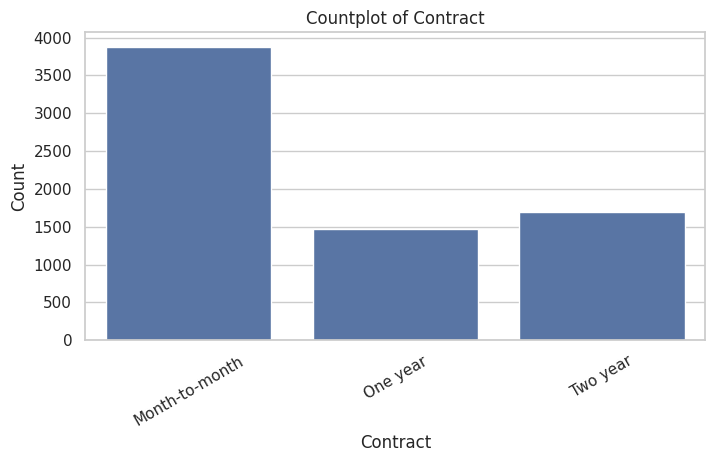

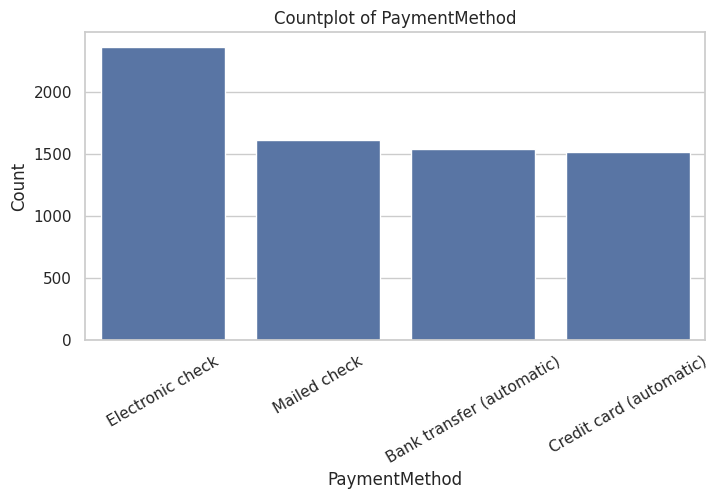

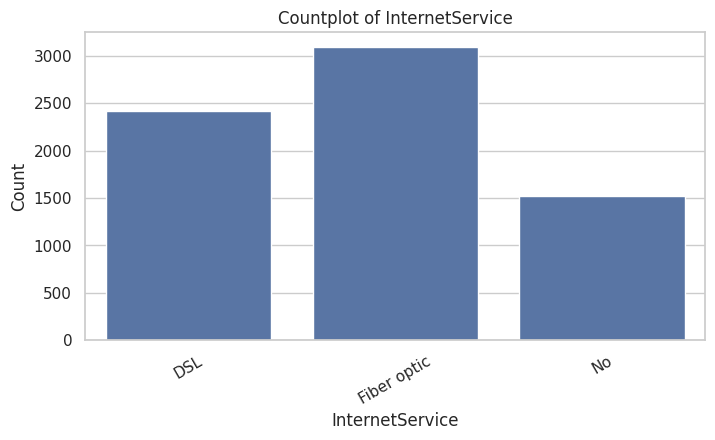

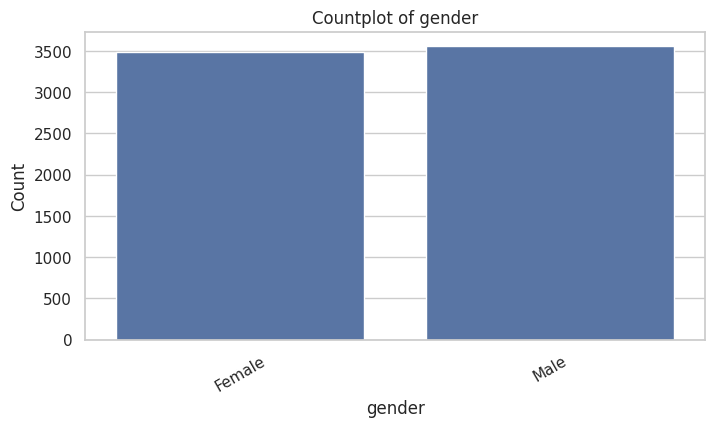

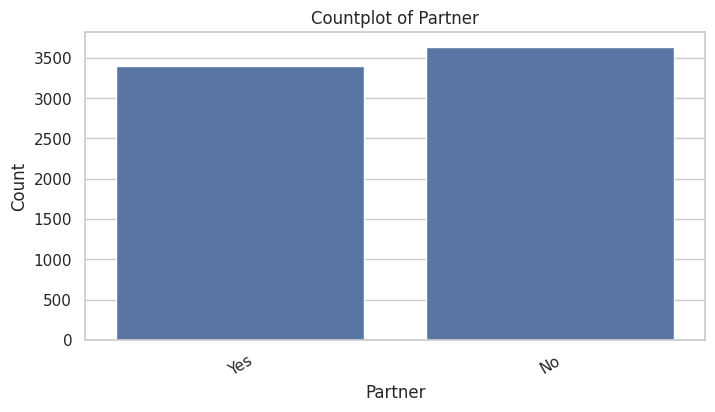

In [39]:
# 주요 범주형 변수 선택
categorical_cols_for_plot = [
    "Contract",
    "PaymentMethod",
    "InternetService",
    "gender",
    "Partner"
]

for col in categorical_cols_for_plot:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Countplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.show()

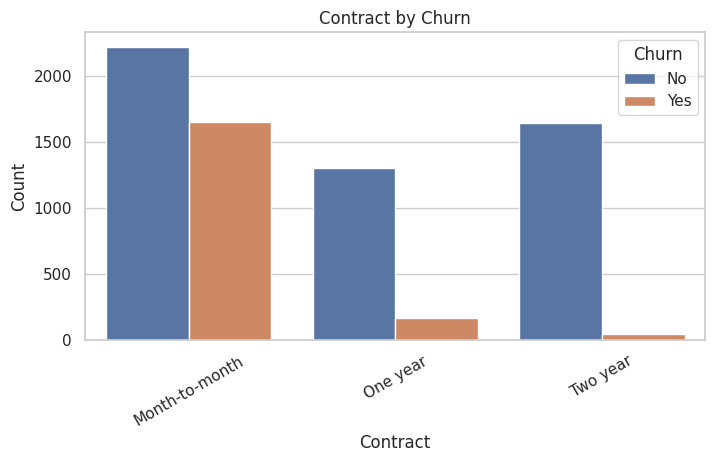

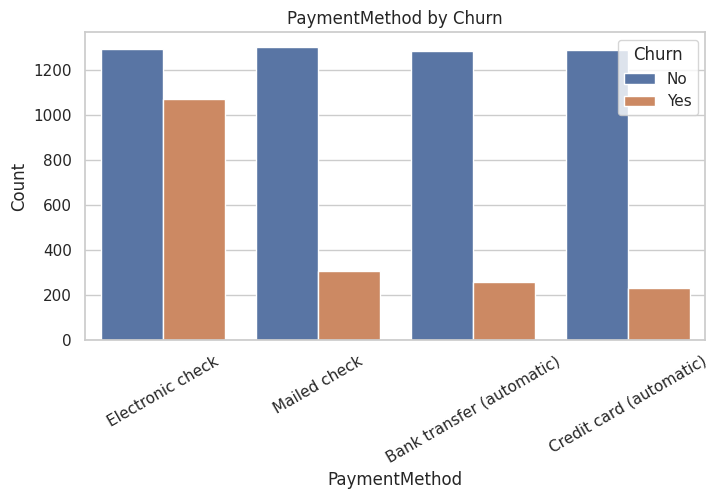

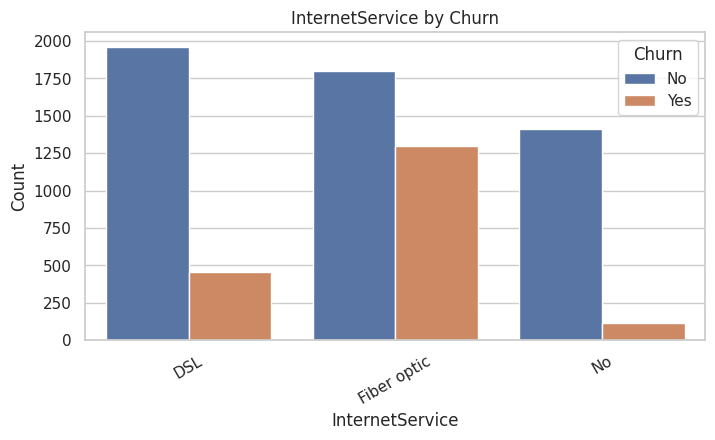

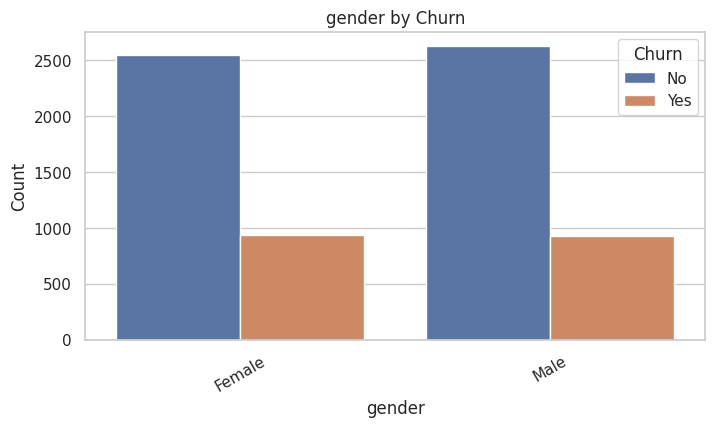

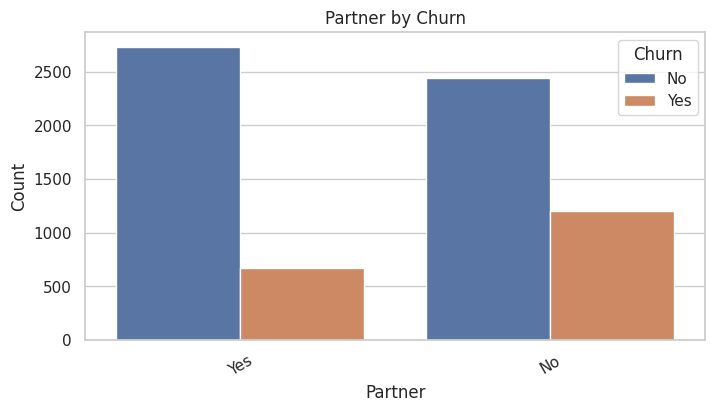

In [40]:
# 주요 범주형 변수별 Churn 분포 확인
for col in categorical_cols_for_plot:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"{col} by Churn")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.legend(title="Churn")
    plt.show()

### 범주형 변수 분포 분석 결과

범주형 변수 중 `Contract`, `PaymentMethod`, `InternetService`는 고객 이탈 여부와 관련성이 있을 가능성이 높다.

특히 월 단위 계약 고객은 장기 계약 고객보다 이탈 비율이 높을 수 있으며, 결제 방식이나 인터넷 서비스 유형에 따라서도 이탈 분포가 달라지는 경향을 확인할 수 있다.

따라서 이후 모델 학습 단계에서 범주형 변수 인코딩 방식이 성능에 영향을 줄 가능성이 있다.

## 2-6. 상관관계 분석

수치형 변수와 타겟 변수를 숫자형으로 변환한 뒤 상관관계를 확인한다.  
이를 통해 각 수치형 변수가 고객 이탈 여부와 어느 정도 선형 관계를 갖는지 파악한다.

In [41]:
# 상관관계 분석을 위해 Churn을 숫자형으로 변환
df_corr = df.copy()
df_corr["Churn_encoded"] = df_corr["Churn"].map({"No": 0, "Yes": 1})

# 수치형 변수와 타겟 변수만 선택
corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn_encoded"]

corr_data = df_corr[corr_cols]

corr_data.head()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn_encoded
0,1,29.85,29.85,0,0
1,34,56.95,1889.50,0,0
2,2,53.85,108.15,0,1
3,45,42.30,1840.75,0,0
4,2,70.70,151.65,0,1


In [42]:
# 상관계수 계산
corr_matrix = corr_data.corr()

corr_matrix

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn_encoded
tenure,1.000000,0.247900,0.825880,0.016567,-0.352229
MonthlyCharges,0.247900,1.000000,0.651065,0.220173,0.193356
TotalCharges,0.825880,0.651065,1.000000,0.102411,-0.199484
SeniorCitizen,0.016567,0.220173,0.102411,1.000000,0.150889
Churn_encoded,-0.352229,0.193356,-0.199484,0.150889,1.000000


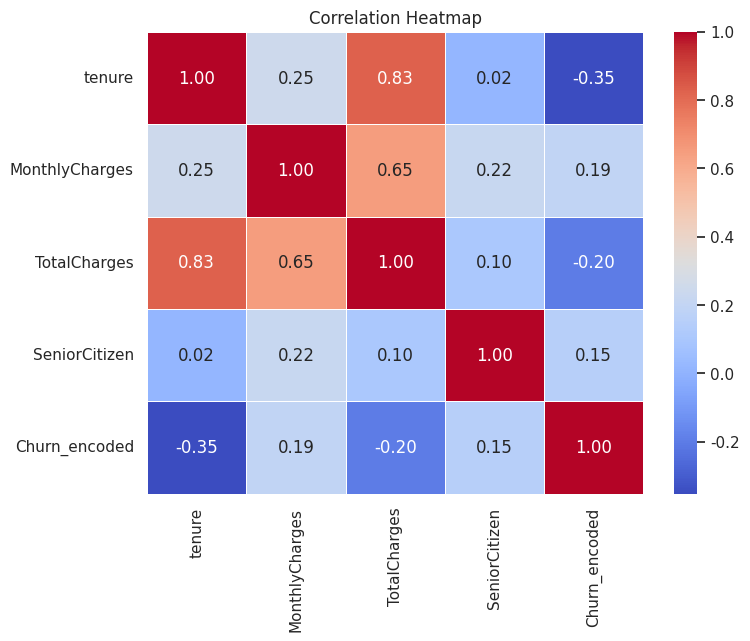

In [43]:
# 상관관계 Heatmap 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

### 상관관계 분석 결과

상관관계 분석 결과, `tenure`는 `Churn_encoded`와 음의 상관관계를 보일 가능성이 있다.  
이는 서비스 이용 기간이 긴 고객일수록 이탈 가능성이 낮아지는 경향을 의미한다.

`MonthlyCharges`는 이탈 여부와 양의 상관관계를 보일 수 있으며, 월 청구 금액이 높은 고객일수록 이탈 가능성이 증가할 수 있음을 시사한다.

`TotalCharges`는 이용 기간과 월 청구 금액의 영향을 동시에 받기 때문에 `tenure`와 높은 상관관계를 가질 수 있다.

## 2-7. 수치형 변수와 Churn 관계 분석

수치형 변수의 분포가 이탈 여부에 따라 어떻게 달라지는지 확인한다.

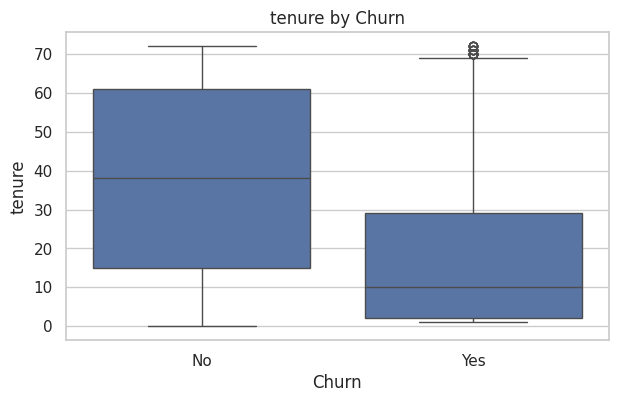

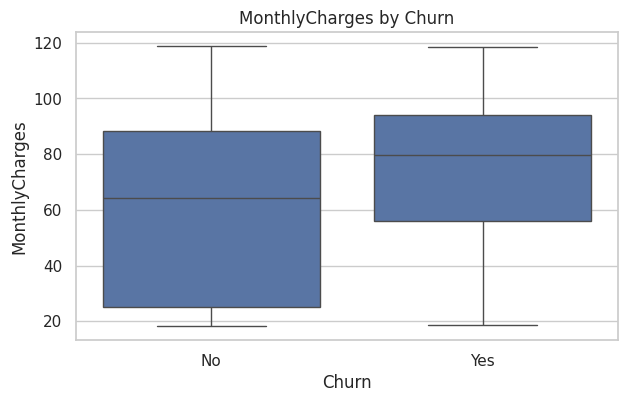

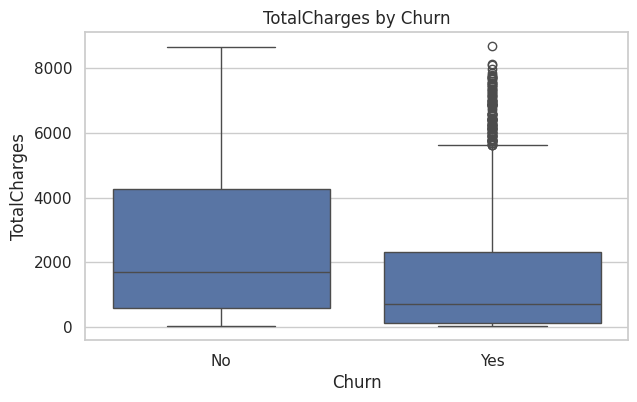

In [44]:
# Churn 여부에 따른 수치형 변수 분포 비교
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

In [45]:
# Churn 여부에 따른 수치형 변수 평균 비교
df.groupby("Churn")[numeric_cols].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.569965,61.265124,2555.344141
Yes,17.979133,74.441332,1531.796094


### Churn별 수치형 변수 분석 결과

이탈 고객과 비이탈 고객을 비교하면, 이탈 고객은 상대적으로 `tenure`가 짧고 `MonthlyCharges`가 높은 경향을 보일 수 있다.

이는 고객이 서비스를 오래 이용할수록 이탈 가능성이 낮아지고, 월 요금 부담이 클수록 이탈 가능성이 높아질 수 있음을 의미한다.

따라서 이후 Feature Engineering 단계에서 `tenure`와 `MonthlyCharges`, `TotalCharges`를 활용한 파생 변수를 생성할 필요가 있다.

## STEP 02 종합 정리

EDA 결과, 본 데이터셋은 다음과 같은 특징을 보였다.

1. 데이터 품질 문제
   - `TotalCharges` 컬럼은 숫자형 변수이지만 원본 데이터에서 object 타입으로 저장되어 있었다.
   - 숫자형 변환 과정에서 일부 공백 값이 결측치로 처리되었다.
   - 결측치 비율은 낮지만, 모델 학습을 위해 적절한 결측치 처리가 필요하다.

2. 타겟 변수 불균형
   - 타겟 변수 `Churn`은 `No` 클래스가 `Yes` 클래스보다 더 많은 분포를 보였다.
   - 따라서 데이터는 다소 불균형한 이진 분류 문제이다.
   - 모델 평가 시 Accuracy만 사용하기보다 Precision, Recall, F1-score, ROC-AUC를 함께 고려해야 한다.

3. 주요 변수 특징
   - `tenure`는 고객의 서비스 이용 기간을 의미하며, 이탈 여부와 관련성이 큰 변수로 보인다.
   - `MonthlyCharges`는 월 요금 수준을 나타내며, 이탈 고객과 비이탈 고객 간 차이가 있을 수 있다.
   - `TotalCharges`는 이용 기간과 월 요금의 영향을 동시에 받는 변수이다.
   - `Contract`, `PaymentMethod`, `InternetService`와 같은 범주형 변수는 고객 이탈 여부에 따라 분포 차이를 보인다.

4. 이후 분석 방향
   - 결측치 처리 방식에 따른 성능 차이를 비교한다.
   - 범주형 변수 인코딩 방식에 따른 성능 차이를 비교한다.
   - 스케일링 방식에 따른 모델 성능 변화를 확인한다.
   - `tenure`, `MonthlyCharges`, `TotalCharges`를 활용하여 파생 변수를 생성한다.

# STEP 03. Feature Engineering 파이프라인 구현

본 단계에서는 머신러닝 모델 학습을 위한 특성 공학 파이프라인을 구현한다.

수행 내용은 다음과 같다.

1. 파생 변수 생성
2. 결측치 처리 전략 비교
3. 범주형 인코딩 전략 비교
4. 스케일링 전략 비교
5. 실험별 전처리 파이프라인 구성

본 과제의 필수 비교 실험 조건에 맞추어 다음 실험 조합을 구성한다.

| 실험 | 결측치 처리 | 인코딩 | 스케일링 | Feature Selection |
|---|---|---|---|---|
| Base | 없음 | 없음 | 없음 | 없음 |
| Exp-1 | Mean | One-Hot | StandardScaler | X |
| Exp-2 | Median | Label Encoding | MinMaxScaler | O |
| Exp-3 | Most Frequent | One-Hot | RobustScaler | O |

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import pandas as pd
import numpy as np

## 3-1. 파생 변수 생성

본 데이터셋의 주요 수치형 변수인 `tenure`, `MonthlyCharges`, `TotalCharges`를 활용하여 파생 변수를 생성한다.

생성할 파생 변수는 다음과 같다.

1. `TenureGroup`
   - 고객의 서비스 이용 기간을 구간화한 변수
   - 신규 고객, 단기 고객, 중기 고객, 장기 고객 등으로 구분

2. `ChargesRatio`
   - `MonthlyCharges / TotalCharges`
   - 총 청구 금액 대비 월 청구 금액의 비율

3. `AvgChargePerTenure`
   - `TotalCharges / tenure`
   - 이용 기간 1개월당 평균 청구 금액

단, `tenure`가 0인 경우 나눗셈 오류가 발생할 수 있으므로 0을 NaN으로 대체하여 계산한다.

In [47]:
def create_features(data):
    """
    Telco Customer Churn Dataset에 대한 파생 변수 생성 함수
    """
    df_fe = data.copy()

    # TotalCharges를 숫자형으로 변환
    df_fe["TotalCharges"] = pd.to_numeric(df_fe["TotalCharges"], errors="coerce")

    # 1. TenureGroup: 이용 기간 구간화
    df_fe["TenureGroup"] = pd.cut(
        df_fe["tenure"],
        bins=[-1, 12, 24, 48, 72],
        labels=["0-12", "13-24", "25-48", "49-72"]
    )

    # tenure가 0인 경우 나눗셈 오류 방지를 위해 NaN으로 대체
    tenure_safe = df_fe["tenure"].replace(0, np.nan)

    # 2. ChargesRatio: 월 청구 금액 / 총 청구 금액
    df_fe["ChargesRatio"] = df_fe["MonthlyCharges"] / df_fe["TotalCharges"]

    # 3. AvgChargePerTenure: 총 청구 금액 / 이용 기간
    df_fe["AvgChargePerTenure"] = df_fe["TotalCharges"] / tenure_safe

    # 무한대 값 처리
    df_fe["ChargesRatio"] = df_fe["ChargesRatio"].replace([np.inf, -np.inf], np.nan)
    df_fe["AvgChargePerTenure"] = df_fe["AvgChargePerTenure"].replace([np.inf, -np.inf], np.nan)

    return df_fe

In [48]:
# 파생 변수 생성
df_fe = create_features(df)

# 생성된 파생 변수 확인
df_fe[["tenure", "MonthlyCharges", "TotalCharges",
       "TenureGroup", "ChargesRatio", "AvgChargePerTenure"]].head()

,tenure,MonthlyCharges,TotalCharges,TenureGroup,ChargesRatio,AvgChargePerTenure
0,1,29.85,29.85,0-12,1.000000,29.850000
1,34,56.95,1889.50,25-48,0.030140,55.573529
2,2,53.85,108.15,0-12,0.497920,54.075000
3,45,42.30,1840.75,25-48,0.022980,40.905556
4,2,70.70,151.65,0-12,0.466205,75.825000


In [49]:
# 파생 변수의 결측치 확인
df_fe[["TenureGroup", "ChargesRatio", "AvgChargePerTenure"]].isnull().sum()

,0
TenureGroup,0
ChargesRatio,11
AvgChargePerTenure,11


In [50]:
print("원본 데이터 shape:", df.shape)
print("파생 변수 생성 후 데이터 shape:", df_fe.shape)

원본 데이터 shape: (7043, 21)
파생 변수 생성 후 데이터 shape: (7043, 24)


### 파생 변수 생성 결과

본 단계에서는 고객의 서비스 이용 기간과 요금 정보를 활용하여 3개의 파생 변수를 생성하였다.

`TenureGroup`은 고객의 이용 기간을 구간화한 범주형 변수로, 신규 고객과 장기 고객의 이탈 패턴 차이를 반영하기 위해 생성하였다.

`ChargesRatio`는 월 청구 금액이 총 청구 금액에서 차지하는 비율을 나타내며, 서비스 이용 기간 대비 요금 부담을 간접적으로 반영할 수 있다.

`AvgChargePerTenure`는 고객이 이용 기간 동안 평균적으로 부담한 청구 금액을 나타내며, 요금 수준과 이용 기간을 함께 고려한 변수이다.

이러한 파생 변수는 기존 변수만 사용했을 때보다 고객 이탈 패턴을 더 잘 설명할 가능성이 있다.

## 3-2. 모델 입력 변수와 타겟 변수 재정의

파생 변수가 추가된 데이터셋을 기준으로 모델 입력 변수 `X`와 타겟 변수 `y`를 다시 정의한다.

`customerID`는 고객 식별자이므로 모델 학습에서 제외한다.  
`Churn`은 예측 대상 타겟 변수이므로 입력 변수에서 제외한다.

In [51]:
# 입력 변수와 타겟 변수 정의
X = df_fe.drop(columns=["customerID", "Churn"])
y = df_fe["Churn"].map({"No": 0, "Yes": 1})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 22)
y shape: (7043,)


In [52]:
# 수치형 변수와 범주형 변수 분리
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("수치형 변수:")
print(numeric_features)

print("\n범주형 변수:")
print(categorical_features)

print("\n수치형 변수 개수:", len(numeric_features))
print("범주형 변수 개수:", len(categorical_features))

수치형 변수:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesRatio', 'AvgChargePerTenure']

범주형 변수:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

수치형 변수 개수: 6
범주형 변수 개수: 16


In [53]:
# 학습 데이터와 테스트 데이터 분리
# stratify=y를 사용하여 Churn 클래스 비율을 학습/테스트 데이터에 비슷하게 유지
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\n학습 데이터 타겟 비율:")
print(y_train.value_counts(normalize=True))

print("\n테스트 데이터 타겟 비율:")
print(y_test.value_counts(normalize=True))

X_train shape: (5634, 22)
X_test shape: (1409, 22)
y_train shape: (5634,)
y_test shape: (1409,)

학습 데이터 타겟 비율:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

테스트 데이터 타겟 비율:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## 3-3. 결측치 처리 전략 비교

본 과제에서는 다음 세 가지 결측치 처리 전략을 비교한다.

1. Mean Imputation
   - 수치형 변수의 결측치를 평균값으로 대체

2. Median Imputation
   - 수치형 변수의 결측치를 중앙값으로 대체

3. Most Frequent Imputation
   - 결측치를 가장 자주 등장한 값으로 대체

`TotalCharges` 및 파생 변수 일부에서 결측치가 발생할 수 있으므로, 각 실험 조합에 따라 서로 다른 결측치 처리 전략을 적용한다.

In [54]:
# 결측치 처리기 정의
mean_imputer = SimpleImputer(strategy="mean")
median_imputer = SimpleImputer(strategy="median")
most_frequent_imputer = SimpleImputer(strategy="most_frequent")

print("결측치 처리 전략 정의 완료")

결측치 처리 전략 정의 완료


## 3-4. 범주형 인코딩 전략 비교

머신러닝 모델은 문자열 형태의 범주형 변수를 직접 처리할 수 없으므로 숫자형 변환이 필요하다.

본 과제에서는 다음 두 가지 인코딩 전략을 비교한다.

1. One-Hot Encoding
   - 각 범주를 별도의 이진 변수로 변환
   - 범주 간 순서 관계를 가정하지 않음
   - 범주형 변수 처리에 일반적으로 많이 사용됨

2. Label Encoding 계열 방식
   - 각 범주를 하나의 정수 값으로 변환
   - 본 실험에서는 여러 범주형 컬럼을 파이프라인에서 처리하기 위해 `OrdinalEncoder`를 사용한다.
   - 단, 범주 간 순서가 없는 변수에도 숫자 크기 관계가 생길 수 있다는 한계가 있다.

In [55]:
# One-Hot Encoding
onehot_encoder = OneHotEncoder(handle_unknown="ignore")

# Label Encoding 계열 방식으로 OrdinalEncoder 사용
ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

print("인코딩 전략 정의 완료")

인코딩 전략 정의 완료


## 3-5. 스케일링 전략 비교

수치형 변수의 값 범위가 서로 다르면 일부 모델에서 학습 성능에 영향을 줄 수 있다.

본 과제에서는 다음 세 가지 스케일링 전략을 비교한다.

1. StandardScaler
   - 평균 0, 표준편차 1이 되도록 변환
   - Logistic Regression과 같은 선형 모델에 유용할 수 있음

2. MinMaxScaler
   - 값을 0과 1 사이 범위로 변환
   - 변수의 최소값과 최대값을 기준으로 스케일링

3. RobustScaler
   - 중앙값과 IQR을 기준으로 변환
   - 이상치의 영향을 상대적으로 덜 받음

In [56]:
# 스케일링 전략 정의
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

print("스케일링 전략 정의 완료")

스케일링 전략 정의 완료


## 3-6. 실험별 전처리 파이프라인 구성

과제에서 제시한 실험 비교 항목에 따라 Base, Exp-1, Exp-2, Exp-3의 전처리 파이프라인을 구성한다.

단, Base 실험에서 전처리를 완전히 적용하지 않으면 문자열 변수와 결측치 때문에 Scikit-learn 모델 학습이 불가능하다.  
따라서 본 실험에서는 Base를 다음과 같이 정의한다.

- Base:
  - 결측치가 있는 행 제거
  - 범주형 변수는 기본 Ordinal Encoding 적용
  - 스케일링 미적용
  - Feature Selection 미적용

이후 Exp-1, Exp-2, Exp-3에서는 서로 다른 결측치 처리, 인코딩, 스케일링 조합을 적용하여 성능 차이를 비교한다.

In [57]:
def make_preprocessor(imputer_strategy="mean", encoder_type="onehot", scaler_type="standard"):
    """
    결측치 처리, 인코딩, 스케일링 전략에 따라 ColumnTransformer 생성
    """

    # 결측치 처리 전략 선택
    if imputer_strategy == "mean":
        numeric_imputer = SimpleImputer(strategy="mean")
        categorical_imputer = SimpleImputer(strategy="most_frequent")
    elif imputer_strategy == "median":
        numeric_imputer = SimpleImputer(strategy="median")
        categorical_imputer = SimpleImputer(strategy="most_frequent")
    elif imputer_strategy == "most_frequent":
        numeric_imputer = SimpleImputer(strategy="most_frequent")
        categorical_imputer = SimpleImputer(strategy="most_frequent")
    else:
        raise ValueError("imputer_strategy는 'mean', 'median', 'most_frequent' 중 하나여야 합니다.")

    # 인코딩 전략 선택
    if encoder_type == "onehot":
        encoder = OneHotEncoder(handle_unknown="ignore")
    elif encoder_type == "ordinal":
        encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    else:
        raise ValueError("encoder_type은 'onehot' 또는 'ordinal' 중 하나여야 합니다.")

    # 스케일링 전략 선택
    if scaler_type == "standard":
        scaler = StandardScaler()
    elif scaler_type == "minmax":
        scaler = MinMaxScaler()
    elif scaler_type == "robust":
        scaler = RobustScaler()
    elif scaler_type is None:
        scaler = "passthrough"
    else:
        raise ValueError("scaler_type은 'standard', 'minmax', 'robust', None 중 하나여야 합니다.")

    # 수치형 변수 처리 파이프라인
    numeric_pipeline = Pipeline(steps=[
        ("imputer", numeric_imputer),
        ("scaler", scaler)
    ])

    # 범주형 변수 처리 파이프라인
    categorical_pipeline = Pipeline(steps=[
        ("imputer", categorical_imputer),
        ("encoder", encoder)
    ])

    # 전체 전처리기
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features)
        ]
    )

    return preprocessor

In [58]:
# Exp-1: Mean + One-Hot + StandardScaler
preprocessor_exp1 = make_preprocessor(
    imputer_strategy="mean",
    encoder_type="onehot",
    scaler_type="standard"
)

# Exp-2: Median + Label/Ordinal + MinMaxScaler
preprocessor_exp2 = make_preprocessor(
    imputer_strategy="median",
    encoder_type="ordinal",
    scaler_type="minmax"
)

# Exp-3: Most Frequent + One-Hot + RobustScaler
preprocessor_exp3 = make_preprocessor(
    imputer_strategy="most_frequent",
    encoder_type="onehot",
    scaler_type="robust"
)

print("Exp-1, Exp-2, Exp-3 전처리기 생성 완료")

Exp-1, Exp-2, Exp-3 전처리기 생성 완료


In [59]:
# Base 실험용 데이터 생성
# 결측치가 있는 행 제거 후 Ordinal Encoding만 적용하고 스케일링은 하지 않음

base_data = df_fe.copy()

# customerID 제거
base_data = base_data.drop(columns=["customerID"])

# 타겟 인코딩
base_data["Churn"] = base_data["Churn"].map({"No": 0, "Yes": 1})

# 결측치가 있는 행 제거
base_data = base_data.dropna()

# 입력 변수와 타겟 변수 분리
X_base = base_data.drop(columns=["Churn"])
y_base = base_data["Churn"]

# Base용 수치형/범주형 변수 분리
base_numeric_features = X_base.select_dtypes(include=["int64", "float64"]).columns.tolist()
base_categorical_features = X_base.select_dtypes(include=["object", "category"]).columns.tolist()

# 범주형 변수 Ordinal Encoding
X_base_encoded = X_base.copy()

base_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_base_encoded[base_categorical_features] = base_encoder.fit_transform(
    X_base_encoded[base_categorical_features]
)

print("Base 데이터 생성 완료")
print("X_base_encoded shape:", X_base_encoded.shape)
print("y_base shape:", y_base.shape)
print("Base 수치형 변수:", base_numeric_features)
print("Base 범주형 변수:", base_categorical_features)

Base 데이터 생성 완료
X_base_encoded shape: (7032, 22)
y_base shape: (7032,)
Base 수치형 변수: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesRatio', 'AvgChargePerTenure']
Base 범주형 변수: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


In [60]:
# Base 데이터 Train/Test 분리
X_base_train, X_base_test, y_base_train, y_base_test = train_test_split(
    X_base_encoded,
    y_base,
    test_size=0.2,
    random_state=42,
    stratify=y_base
)

print("X_base_train shape:", X_base_train.shape)
print("X_base_test shape:", X_base_test.shape)
print("y_base_train shape:", y_base_train.shape)
print("y_base_test shape:", y_base_test.shape)

X_base_train shape: (5625, 22)
X_base_test shape: (1407, 22)
y_base_train shape: (5625,)
y_base_test shape: (1407,)


In [61]:
# Exp-1 전처리 결과 확인
X_train_exp1 = preprocessor_exp1.fit_transform(X_train)
X_test_exp1 = preprocessor_exp1.transform(X_test)

print("Exp-1 전처리 후 X_train shape:", X_train_exp1.shape)
print("Exp-1 전처리 후 X_test shape:", X_test_exp1.shape)

Exp-1 전처리 후 X_train shape: (5634, 51)
Exp-1 전처리 후 X_test shape: (1409, 51)


In [62]:
# Exp-2 전처리 결과 확인
X_train_exp2 = preprocessor_exp2.fit_transform(X_train)
X_test_exp2 = preprocessor_exp2.transform(X_test)

# Exp-3 전처리 결과 확인
X_train_exp3 = preprocessor_exp3.fit_transform(X_train)
X_test_exp3 = preprocessor_exp3.transform(X_test)

print("Exp-2 전처리 후 X_train shape:", X_train_exp2.shape)
print("Exp-2 전처리 후 X_test shape:", X_test_exp2.shape)

print("\nExp-3 전처리 후 X_train shape:", X_train_exp3.shape)
print("Exp-3 전처리 후 X_test shape:", X_test_exp3.shape)

Exp-2 전처리 후 X_train shape: (5634, 22)
Exp-2 전처리 후 X_test shape: (1409, 22)

Exp-3 전처리 후 X_train shape: (5634, 51)
Exp-3 전처리 후 X_test shape: (1409, 51)


In [63]:
# 전처리 후 결측치 존재 여부 확인
print("Exp-1 결측치 존재 여부:", np.isnan(X_train_exp1.toarray()).sum() if hasattr(X_train_exp1, "toarray") else np.isnan(X_train_exp1).sum())
print("Exp-2 결측치 존재 여부:", np.isnan(X_train_exp2).sum())
print("Exp-3 결측치 존재 여부:", np.isnan(X_train_exp3.toarray()).sum() if hasattr(X_train_exp3, "toarray") else np.isnan(X_train_exp3).sum())

Exp-1 결측치 존재 여부: 0
Exp-2 결측치 존재 여부: 0
Exp-3 결측치 존재 여부: 0


In [64]:
experiment_summary = pd.DataFrame({
    "실험": ["Base", "Exp-1", "Exp-2", "Exp-3"],
    "결측치 처리": ["Drop NA", "Mean", "Median", "Most Frequent"],
    "인코딩": ["Ordinal Encoding", "One-Hot Encoding", "Ordinal Encoding", "One-Hot Encoding"],
    "스케일링": ["None", "StandardScaler", "MinMaxScaler", "RobustScaler"],
    "파생 변수": ["O", "O", "O", "O"],
    "Feature Selection": ["X", "X", "O", "O"]
})

experiment_summary

,실험,결측치 처리,인코딩,스케일링,파생 변수,Feature Selection
0,Base,Drop NA,Ordinal Encoding,None,O,X
1,Exp-1,Mean,One-Hot Encoding,StandardScaler,O,X
2,Exp-2,Median,Ordinal Encoding,MinMaxScaler,O,O
3,Exp-3,Most Frequent,One-Hot Encoding,RobustScaler,O,O


## STEP 03 정리

본 단계에서는 고객 이탈 예측 성능 향상을 위해 Feature Engineering 파이프라인을 구성하였다.

먼저 `tenure`, `MonthlyCharges`, `TotalCharges`를 활용하여 다음과 같은 파생 변수를 생성하였다.

1. `TenureGroup`
2. `ChargesRatio`
3. `AvgChargePerTenure`

이후 결측치 처리, 범주형 인코딩, 스케일링 전략을 조합하여 실험별 전처리 파이프라인을 구성하였다.

- Exp-1은 Mean Imputation, One-Hot Encoding, StandardScaler를 적용한다.
- Exp-2는 Median Imputation, Ordinal Encoding, MinMaxScaler를 적용한다.
- Exp-3은 Most Frequent Imputation, One-Hot Encoding, RobustScaler를 적용한다.
- Base는 최소한의 처리를 적용한 기준선 모델로 사용한다.

본 단계에서는 Scikit-learn의 `Pipeline`과 `ColumnTransformer`를 활용하여 전처리 과정을 일관성 있게 구성하였다. 이를 통해 데이터 누수를 방지하고, 이후 모델 학습 및 성능 비교 실험을 재현 가능하게 수행할 수 있다.

# STEP 04. 변수 선택 Feature Selection

본 단계에서는 모델 학습에 사용되는 변수 중 예측에 중요한 변수를 선택하기 위해 Feature Selection을 수행한다.

변수 선택 방법으로는 Random Forest Feature Importance를 사용한다.  
Random Forest는 각 변수가 예측 성능에 기여한 정도를 중요도 값으로 제공하므로, 이를 활용하여 중요도가 높은 상위 N개의 변수를 선택할 수 있다.

본 실험에서는 전처리 후 생성된 변수들 중 중요도 상위 20개 변수를 선택한다.

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

## 4-1. 전처리 후 Feature 이름 추출

One-Hot Encoding을 적용하면 하나의 범주형 변수가 여러 개의 더미 변수로 변환된다.  
따라서 Feature Importance를 해석하기 위해 전처리 후 생성된 전체 feature 이름을 추출하는 함수가 필요하다.

In [66]:
def get_feature_names_from_preprocessor(preprocessor):
    """
    ColumnTransformer 전처리 후 생성된 feature 이름을 추출하는 함수
    """
    feature_names = []

    # 수치형 변수 이름 추가
    feature_names.extend(numeric_features)

    # 범주형 변수 처리 부분 가져오기
    cat_pipeline = preprocessor.named_transformers_["cat"]
    encoder = cat_pipeline.named_steps["encoder"]

    # OneHotEncoder인 경우
    if isinstance(encoder, OneHotEncoder):
        cat_feature_names = encoder.get_feature_names_out(categorical_features)
        feature_names.extend(cat_feature_names)

    # OrdinalEncoder인 경우
    elif isinstance(encoder, OrdinalEncoder):
        feature_names.extend(categorical_features)

    return feature_names

## 4-2. Exp-2 Feature Selection

Exp-2 실험은 다음 전처리 조합을 사용한다.

- 결측치 처리: Median Imputation
- 인코딩: Ordinal Encoding
- 스케일링: MinMaxScaler
- Feature Selection: 적용

전처리 후 Random Forest Feature Importance를 기반으로 상위 20개 변수를 선택한다.

In [67]:
# Exp-2 전처리 데이터 준비
X_train_exp2 = preprocessor_exp2.fit_transform(X_train)
X_test_exp2 = preprocessor_exp2.transform(X_test)

# Exp-2 feature 이름 추출
feature_names_exp2 = get_feature_names_from_preprocessor(preprocessor_exp2)

print("Exp-2 전처리 후 feature 개수:", X_train_exp2.shape[1])
print("Exp-2 feature 이름 개수:", len(feature_names_exp2))

Exp-2 전처리 후 feature 개수: 22
Exp-2 feature 이름 개수: 22


In [68]:
# Feature Importance 계산용 Random Forest 모델
rf_selector_exp2 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_selector_exp2.fit(X_train_exp2, y_train)

# Feature Importance DataFrame 생성
importance_exp2 = pd.DataFrame({
    "Feature": feature_names_exp2,
    "Importance": rf_selector_exp2.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_exp2.head(20)

,Feature,Importance
4,ChargesRatio,0.122115
5,AvgChargePerTenure,0.114499
2,MonthlyCharges,0.114476
3,TotalCharges,0.109690
18,Contract,0.093398
1,tenure,0.090725
15,TechSupport,0.048610
12,OnlineSecurity,0.047047
20,PaymentMethod,0.039887
11,InternetService,0.028554


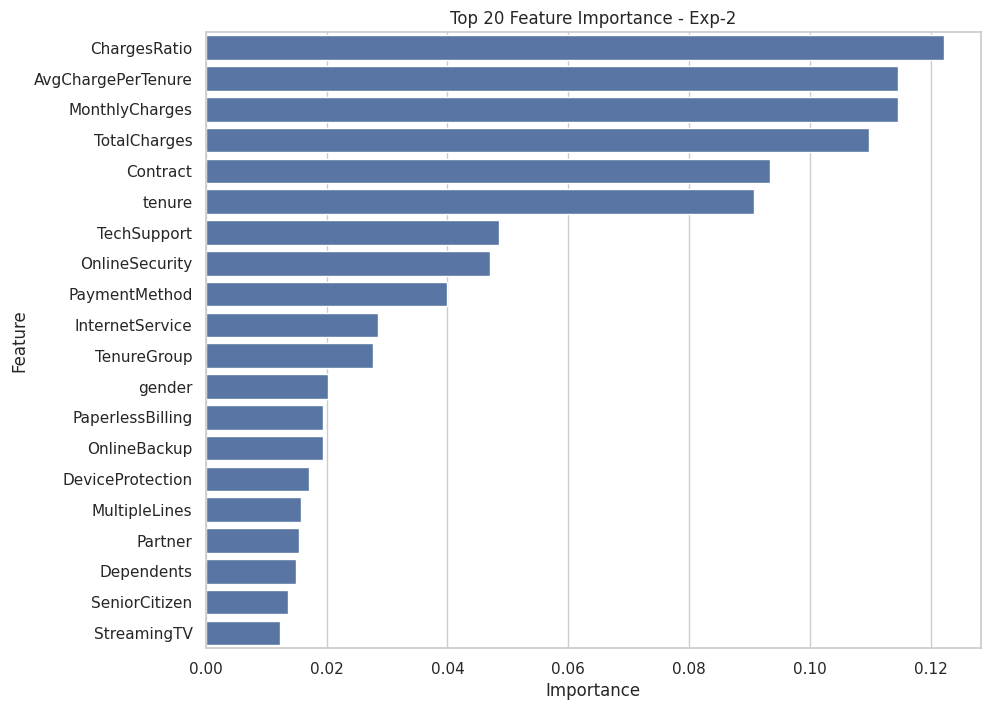

In [69]:
# Exp-2 Feature Importance 상위 20개 시각화
top_n = 20
top_features_exp2 = importance_exp2.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_features_exp2,
    x="Importance",
    y="Feature"
)
plt.title("Top 20 Feature Importance - Exp-2")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [70]:
# Exp-2 상위 20개 변수 이름 저장
selected_features_exp2 = importance_exp2.head(20)["Feature"].tolist()

print("Exp-2 선택된 상위 20개 변수:")
for i, feature in enumerate(selected_features_exp2, start=1):
    print(f"{i}. {feature}")

Exp-2 선택된 상위 20개 변수:
1. ChargesRatio
2. AvgChargePerTenure
3. MonthlyCharges
4. TotalCharges
5. Contract
6. tenure
7. TechSupport
8. OnlineSecurity
9. PaymentMethod
10. InternetService
11. TenureGroup
12. gender
13. PaperlessBilling
14. OnlineBackup
15. DeviceProtection
16. MultipleLines
17. Partner
18. Dependents
19. SeniorCitizen
20. StreamingTV


In [71]:
# 상위 20개 변수 인덱스 추출
selected_indices_exp2 = [
    feature_names_exp2.index(feature) for feature in selected_features_exp2
]

# 선택된 변수만 사용한 데이터 생성
X_train_exp2_selected = X_train_exp2[:, selected_indices_exp2]
X_test_exp2_selected = X_test_exp2[:, selected_indices_exp2]

print("Exp-2 Feature Selection 전:", X_train_exp2.shape)
print("Exp-2 Feature Selection 후:", X_train_exp2_selected.shape)

Exp-2 Feature Selection 전: (5634, 22)
Exp-2 Feature Selection 후: (5634, 20)


## 4-3. Exp-3 Feature Selection

Exp-3 실험은 다음 전처리 조합을 사용한다.

- 결측치 처리: Most Frequent Imputation
- 인코딩: One-Hot Encoding
- 스케일링: RobustScaler
- Feature Selection: 적용

전처리 후 Random Forest Feature Importance를 기반으로 상위 20개 변수를 선택한다.

In [72]:
# Exp-3 전처리 데이터 준비
X_train_exp3 = preprocessor_exp3.fit_transform(X_train)
X_test_exp3 = preprocessor_exp3.transform(X_test)

# Exp-3 feature 이름 추출
feature_names_exp3 = get_feature_names_from_preprocessor(preprocessor_exp3)

print("Exp-3 전처리 후 feature 개수:", X_train_exp3.shape[1])
print("Exp-3 feature 이름 개수:", len(feature_names_exp3))

Exp-3 전처리 후 feature 개수: 51
Exp-3 feature 이름 개수: 51


In [73]:
# Feature Importance 계산용 Random Forest 모델
rf_selector_exp3 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_selector_exp3.fit(X_train_exp3, y_train)

# Feature Importance DataFrame 생성
importance_exp3 = pd.DataFrame({
    "Feature": feature_names_exp3,
    "Importance": rf_selector_exp3.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_exp3.head(20)

,Feature,Importance
4,ChargesRatio,0.100615
3,TotalCharges,0.093032
5,AvgChargePerTenure,0.089869
2,MonthlyCharges,0.089059
1,tenure,0.080319
38,Contract_Month-to-month,0.067377
29,TechSupport_No,0.032264
20,OnlineSecurity_No,0.031280
40,Contract_Two year,0.028697
18,InternetService_Fiber optic,0.025495


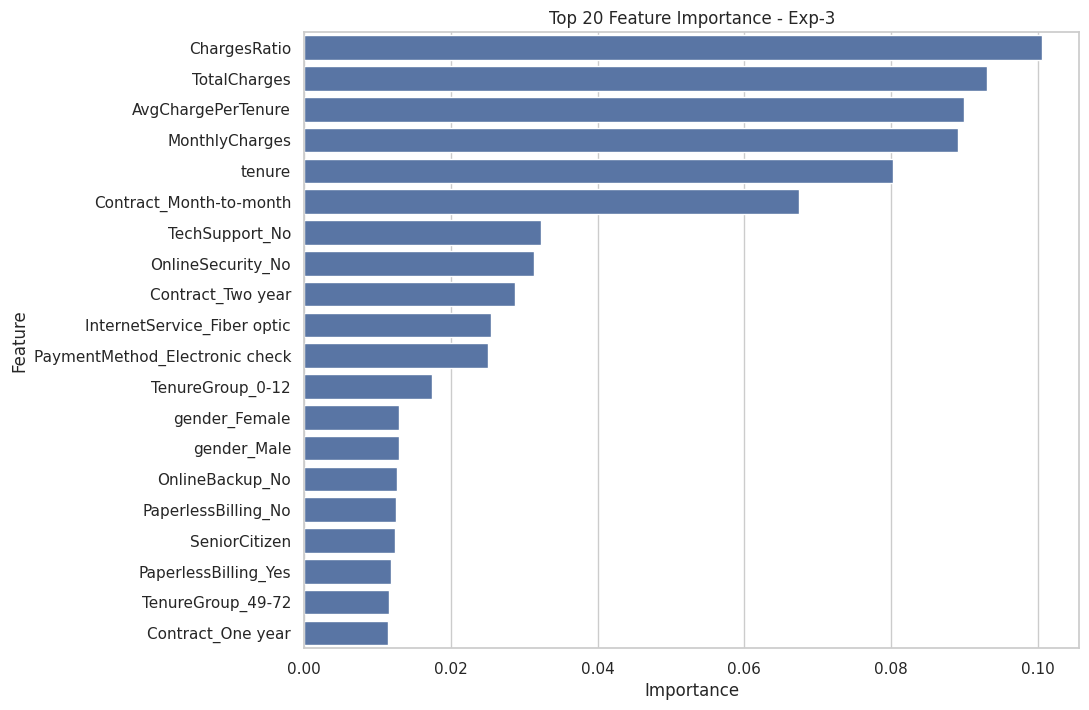

In [74]:
# Exp-3 Feature Importance 상위 20개 시각화
top_n = 20
top_features_exp3 = importance_exp3.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_features_exp3,
    x="Importance",
    y="Feature"
)
plt.title("Top 20 Feature Importance - Exp-3")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [75]:
# Exp-3 상위 20개 변수 이름 저장
selected_features_exp3 = importance_exp3.head(20)["Feature"].tolist()

print("Exp-3 선택된 상위 20개 변수:")
for i, feature in enumerate(selected_features_exp3, start=1):
    print(f"{i}. {feature}")

Exp-3 선택된 상위 20개 변수:
1. ChargesRatio
2. TotalCharges
3. AvgChargePerTenure
4. MonthlyCharges
5. tenure
6. Contract_Month-to-month
7. TechSupport_No
8. OnlineSecurity_No
9. Contract_Two year
10. InternetService_Fiber optic
11. PaymentMethod_Electronic check
12. TenureGroup_0-12
13. gender_Female
14. gender_Male
15. OnlineBackup_No
16. PaperlessBilling_No
17. SeniorCitizen
18. PaperlessBilling_Yes
19. TenureGroup_49-72
20. Contract_One year


In [76]:
# 상위 20개 변수 인덱스 추출
selected_indices_exp3 = [
    feature_names_exp3.index(feature) for feature in selected_features_exp3
]

# 선택된 변수만 사용한 데이터 생성
X_train_exp3_selected = X_train_exp3[:, selected_indices_exp3]
X_test_exp3_selected = X_test_exp3[:, selected_indices_exp3]

print("Exp-3 Feature Selection 전:", X_train_exp3.shape)
print("Exp-3 Feature Selection 후:", X_train_exp3_selected.shape)

Exp-3 Feature Selection 전: (5634, 51)
Exp-3 Feature Selection 후: (5634, 20)


## 4-4. 변수 선택 결과 비교

Exp-2와 Exp-3에 대해 Random Forest Feature Importance 기반 변수 선택을 수행하였다.

각 실험에서는 중요도 상위 20개 변수를 선택하여 이후 모델 학습 단계에서 사용한다.

In [77]:
feature_selection_summary = pd.DataFrame({
    "실험": ["Exp-2", "Exp-3"],
    "Feature Selection 방법": [
        "Random Forest Feature Importance",
        "Random Forest Feature Importance"
    ],
    "선택 전 Feature 수": [
        X_train_exp2.shape[1],
        X_train_exp3.shape[1]
    ],
    "선택 후 Feature 수": [
        X_train_exp2_selected.shape[1],
        X_train_exp3_selected.shape[1]
    ],
    "선택 기준": [
        "Importance 상위 20개",
        "Importance 상위 20개"
    ]
})

feature_selection_summary

,실험,Feature Selection 방법,선택 전 Feature 수,선택 후 Feature 수,선택 기준
0,Exp-2,Random Forest Feature Importance,22,20,Importance 상위 20개
1,Exp-3,Random Forest Feature Importance,51,20,Importance 상위 20개


In [78]:
selected_feature_table = pd.DataFrame({
    "Rank": range(1, 21),
    "Exp-2 Selected Features": selected_features_exp2,
    "Exp-3 Selected Features": selected_features_exp3
})

selected_feature_table

,Rank,Exp-2 Selected Features,Exp-3 Selected Features
0,1,ChargesRatio,ChargesRatio
1,2,AvgChargePerTenure,TotalCharges
2,3,MonthlyCharges,AvgChargePerTenure
3,4,TotalCharges,MonthlyCharges
4,5,Contract,tenure
5,6,tenure,Contract_Month-to-month
6,7,TechSupport,TechSupport_No
7,8,OnlineSecurity,OnlineSecurity_No
8,9,PaymentMethod,Contract_Two year
9,10,InternetService,InternetService_Fiber optic


## STEP 04 정리

본 단계에서는 Random Forest Feature Importance를 활용하여 변수 선택을 수행하였다.

Exp-2와 Exp-3 실험에서 각각 전처리 후 생성된 feature를 대상으로 중요도를 계산하였고, 중요도 상위 20개 변수를 선택하였다.

Exp-2는 Ordinal Encoding을 사용하므로 전처리 후 feature 수가 비교적 적게 유지되었다. 반면 Exp-3는 One-Hot Encoding을 사용하므로 범주형 변수가 여러 개의 더미 변수로 확장되어 feature 수가 증가하였다.

Feature Selection을 통해 중요도가 낮은 변수를 제거함으로써 모델 복잡도를 줄이고, 과적합 가능성을 완화할 수 있다. 이후 모델 학습 단계에서는 Feature Selection 적용 전과 후의 성능을 비교하여 실제 성능 향상 여부를 확인한다.

# STEP 05. 모델 학습 및 평가

본 단계에서는 앞서 구성한 Feature Engineering 파이프라인과 Feature Selection 결과를 바탕으로 머신러닝 모델을 학습하고 성능을 평가한다.

본 과제에서는 Classification 문제에 해당하므로 다음 모델을 사용한다.

1. Logistic Regression
2. Random Forest Classifier

성능 평가지표는 다음과 같다.

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

또한 Base, Exp-1, Exp-2, Exp-3 실험 조합별 성능을 비교하고, Feature Selection 적용 전과 후의 성능 차이를 분석한다.

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

import pandas as pd
import numpy as np

In [80]:
def evaluate_model(model, X_train, X_test, y_train, y_test, experiment_name, model_name):
    """
    모델 학습 및 평가 결과를 DataFrame 형태로 반환하는 함수
    """
    # 모델 학습
    model.fit(X_train, y_train)

    # 예측
    y_pred = model.predict(X_test)

    # ROC-AUC 계산을 위한 확률값
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    # 평가 지표 계산
    result = {
        "Experiment": experiment_name,
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc
    }

    return result

In [81]:
# 실험 결과 저장 리스트
results = []

## 5-1. Base 모델 학습 및 평가

Base 실험은 전처리 효과 비교를 위한 기준선이다.

본 실험에서는 다음과 같이 최소한의 처리만 적용한 데이터를 사용한다.

- 결측치가 있는 행 제거
- 범주형 변수 Ordinal Encoding
- 스케일링 미적용
- Feature Selection 미적용

이 데이터를 바탕으로 Logistic Regression과 Random Forest 모델을 학습한다.

In [82]:
# Base - Logistic Regression
base_lr = LogisticRegression(max_iter=1000, random_state=42)

results.append(
    evaluate_model(
        model=base_lr,
        X_train=X_base_train,
        X_test=X_base_test,
        y_train=y_base_train,
        y_test=y_base_test,
        experiment_name="Base",
        model_name="Logistic Regression"
    )
)

print("Base Logistic Regression 평가 완료")

Base Logistic Regression 평가 완료


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [83]:
# Base - Random Forest
base_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

results.append(
    evaluate_model(
        model=base_rf,
        X_train=X_base_train,
        X_test=X_base_test,
        y_train=y_base_train,
        y_test=y_base_test,
        experiment_name="Base",
        model_name="Random Forest"
    )
)

print("Base Random Forest 평가 완료")

Base Random Forest 평가 완료


## 5-2. Exp-1 모델 학습 및 평가

Exp-1 실험은 다음 전처리 조합을 사용한다.

- 결측치 처리: Mean Imputation
- 인코딩: One-Hot Encoding
- 스케일링: StandardScaler
- Feature Selection: 미적용

전처리기는 STEP 03에서 생성한 `preprocessor_exp1`을 사용한다.

In [84]:
# Exp-1 전처리 데이터 준비
X_train_exp1 = preprocessor_exp1.fit_transform(X_train)
X_test_exp1 = preprocessor_exp1.transform(X_test)

print("Exp-1 X_train shape:", X_train_exp1.shape)
print("Exp-1 X_test shape:", X_test_exp1.shape)

Exp-1 X_train shape: (5634, 51)
Exp-1 X_test shape: (1409, 51)


In [85]:
# Exp-1 - Logistic Regression
exp1_lr = LogisticRegression(max_iter=1000, random_state=42)

results.append(
    evaluate_model(
        model=exp1_lr,
        X_train=X_train_exp1,
        X_test=X_test_exp1,
        y_train=y_train,
        y_test=y_test,
        experiment_name="Exp-1",
        model_name="Logistic Regression"
    )
)

print("Exp-1 Logistic Regression 평가 완료")

Exp-1 Logistic Regression 평가 완료


In [86]:
# Exp-1 - Random Forest
exp1_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

results.append(
    evaluate_model(
        model=exp1_rf,
        X_train=X_train_exp1,
        X_test=X_test_exp1,
        y_train=y_train,
        y_test=y_test,
        experiment_name="Exp-1",
        model_name="Random Forest"
    )
)

print("Exp-1 Random Forest 평가 완료")

Exp-1 Random Forest 평가 완료


## 5-3. Exp-2 모델 학습 및 평가

Exp-2 실험은 다음 전처리 조합을 사용한다.

- 결측치 처리: Median Imputation
- 인코딩: Ordinal Encoding
- 스케일링: MinMaxScaler
- Feature Selection: 적용

Feature Selection의 효과를 확인하기 위해 선택 전 전체 feature를 사용한 경우와, Random Forest Feature Importance 기반 상위 20개 feature만 사용한 경우를 모두 평가한다.

In [87]:
# Exp-2 전체 feature - Logistic Regression
exp2_lr_all = LogisticRegression(max_iter=1000, random_state=42)

results.append(
    evaluate_model(
        model=exp2_lr_all,
        X_train=X_train_exp2,
        X_test=X_test_exp2,
        y_train=y_train,
        y_test=y_test,
        experiment_name="Exp-2 All Features",
        model_name="Logistic Regression"
    )
)

print("Exp-2 전체 feature Logistic Regression 평가 완료")

Exp-2 전체 feature Logistic Regression 평가 완료


In [88]:
# Exp-2 전체 feature - Random Forest
exp2_rf_all = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

results.append(
    evaluate_model(
        model=exp2_rf_all,
        X_train=X_train_exp2,
        X_test=X_test_exp2,
        y_train=y_train,
        y_test=y_test,
        experiment_name="Exp-2 All Features",
        model_name="Random Forest"
    )
)

print("Exp-2 전체 feature Random Forest 평가 완료")

Exp-2 전체 feature Random Forest 평가 완료


In [89]:
# Exp-2 선택 feature - Logistic Regression
exp2_lr_selected = LogisticRegression(max_iter=1000, random_state=42)

results.append(
    evaluate_model(
        model=exp2_lr_selected,
        X_train=X_train_exp2_selected,
        X_test=X_test_exp2_selected,
        y_train=y_train,
        y_test=y_test,
        experiment_name="Exp-2 Selected Features",
        model_name="Logistic Regression"
    )
)

print("Exp-2 선택 feature Logistic Regression 평가 완료")

Exp-2 선택 feature Logistic Regression 평가 완료


In [90]:
# Exp-2 선택 feature - Random Forest
exp2_rf_selected = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

results.append(
    evaluate_model(
        model=exp2_rf_selected,
        X_train=X_train_exp2_selected,
        X_test=X_test_exp2_selected,
        y_train=y_train,
        y_test=y_test,
        experiment_name="Exp-2 Selected Features",
        model_name="Random Forest"
    )
)

print("Exp-2 선택 feature Random Forest 평가 완료")

Exp-2 선택 feature Random Forest 평가 완료


## 5-4. Exp-3 모델 학습 및 평가

Exp-3 실험은 다음 전처리 조합을 사용한다.

- 결측치 처리: Most Frequent Imputation
- 인코딩: One-Hot Encoding
- 스케일링: RobustScaler
- Feature Selection: 적용

Exp-3 역시 Feature Selection 효과를 확인하기 위해 전체 feature 사용 결과와 선택 feature 사용 결과를 비교한다.

In [91]:
# Exp-3 전체 feature - Logistic Regression
exp3_lr_all = LogisticRegression(max_iter=1000, random_state=42)

results.append(
    evaluate_model(
        model=exp3_lr_all,
        X_train=X_train_exp3,
        X_test=X_test_exp3,
        y_train=y_train,
        y_test=y_test,
        experiment_name="Exp-3 All Features",
        model_name="Logistic Regression"
    )
)

print("Exp-3 전체 feature Logistic Regression 평가 완료")

Exp-3 전체 feature Logistic Regression 평가 완료


In [92]:
# Exp-3 전체 feature - Random Forest
exp3_rf_all = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

results.append(
    evaluate_model(
        model=exp3_rf_all,
        X_train=X_train_exp3,
        X_test=X_test_exp3,
        y_train=y_train,
        y_test=y_test,
        experiment_name="Exp-3 All Features",
        model_name="Random Forest"
    )
)

print("Exp-3 전체 feature Random Forest 평가 완료")

Exp-3 전체 feature Random Forest 평가 완료


In [93]:
# Exp-3 선택 feature - Logistic Regression
exp3_lr_selected = LogisticRegression(max_iter=1000, random_state=42)

results.append(
    evaluate_model(
        model=exp3_lr_selected,
        X_train=X_train_exp3_selected,
        X_test=X_test_exp3_selected,
        y_train=y_train,
        y_test=y_test,
        experiment_name="Exp-3 Selected Features",
        model_name="Logistic Regression"
    )
)

print("Exp-3 선택 feature Logistic Regression 평가 완료")

Exp-3 선택 feature Logistic Regression 평가 완료


In [94]:
# Exp-3 선택 feature - Random Forest
exp3_rf_selected = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

results.append(
    evaluate_model(
        model=exp3_rf_selected,
        X_train=X_train_exp3_selected,
        X_test=X_test_exp3_selected,
        y_train=y_train,
        y_test=y_test,
        experiment_name="Exp-3 Selected Features",
        model_name="Random Forest"
    )
)

print("Exp-3 선택 feature Random Forest 평가 완료")

Exp-3 선택 feature Random Forest 평가 완료


## 5-5. 전체 성능 비교표

Base, Exp-1, Exp-2, Exp-3 실험 결과를 하나의 표로 정리한다.

성능 비교 지표는 Accuracy, Precision, Recall, F1-score, ROC-AUC를 사용한다.

In [95]:
# 전체 결과 DataFrame 생성
results_df = pd.DataFrame(results)

# 보기 좋게 소수점 정리
results_df_rounded = results_df.copy()
metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
results_df_rounded[metric_cols] = results_df_rounded[metric_cols].round(4)

results_df_rounded

,Experiment,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Base,Logistic Regression,0.7960,0.6330,0.5535,0.5906,0.8387
1,Base,Random Forest,0.7875,0.6298,0.4866,0.5490,0.8172
2,Exp-1,Logistic Regression,0.8070,0.6700,0.5374,0.5964,0.8480
3,Exp-1,Random Forest,0.7779,0.6041,0.4733,0.5307,0.8234
4,Exp-2 All Features,Logistic Regression,0.8041,0.6623,0.5348,0.5917,0.8472
5,Exp-2 All Features,Random Forest,0.7885,0.6338,0.4813,0.5471,0.8242
6,Exp-2 Selected Features,Logistic Regression,0.8006,0.6515,0.5348,0.5874,0.8423
7,Exp-2 Selected Features,Random Forest,0.7807,0.6140,0.4679,0.5311,0.8214
8,Exp-3 All Features,Logistic Regression,0.8055,0.6678,0.5321,0.5923,0.8482
9,Exp-3 All Features,Random Forest,0.7779,0.6041,0.4733,0.5307,0.8224


In [96]:
# F1-score 기준으로 성능 정렬
results_df_rounded.sort_values(by="F1-score", ascending=False)

,Experiment,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Exp-1,Logistic Regression,0.8070,0.6700,0.5374,0.5964,0.8480
8,Exp-3 All Features,Logistic Regression,0.8055,0.6678,0.5321,0.5923,0.8482
4,Exp-2 All Features,Logistic Regression,0.8041,0.6623,0.5348,0.5917,0.8472
0,Base,Logistic Regression,0.7960,0.6330,0.5535,0.5906,0.8387
10,Exp-3 Selected Features,Logistic Regression,0.8041,0.6633,0.5321,0.5905,0.8450
6,Exp-2 Selected Features,Logistic Regression,0.8006,0.6515,0.5348,0.5874,0.8423
1,Base,Random Forest,0.7875,0.6298,0.4866,0.5490,0.8172
5,Exp-2 All Features,Random Forest,0.7885,0.6338,0.4813,0.5471,0.8242
11,Exp-3 Selected Features,Random Forest,0.7828,0.6181,0.4759,0.5378,0.8178
7,Exp-2 Selected Features,Random Forest,0.7807,0.6140,0.4679,0.5311,0.8214


In [97]:
# ROC-AUC 기준으로 성능 정렬
results_df_rounded.sort_values(by="ROC-AUC", ascending=False)

,Experiment,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
8,Exp-3 All Features,Logistic Regression,0.8055,0.6678,0.5321,0.5923,0.8482
2,Exp-1,Logistic Regression,0.8070,0.6700,0.5374,0.5964,0.8480
4,Exp-2 All Features,Logistic Regression,0.8041,0.6623,0.5348,0.5917,0.8472
10,Exp-3 Selected Features,Logistic Regression,0.8041,0.6633,0.5321,0.5905,0.8450
6,Exp-2 Selected Features,Logistic Regression,0.8006,0.6515,0.5348,0.5874,0.8423
0,Base,Logistic Regression,0.7960,0.6330,0.5535,0.5906,0.8387
5,Exp-2 All Features,Random Forest,0.7885,0.6338,0.4813,0.5471,0.8242
3,Exp-1,Random Forest,0.7779,0.6041,0.4733,0.5307,0.8234
9,Exp-3 All Features,Random Forest,0.7779,0.6041,0.4733,0.5307,0.8224
7,Exp-2 Selected Features,Random Forest,0.7807,0.6140,0.4679,0.5311,0.8214


## 5-6. 실험 조합별 성능 비교표

과제에서 요구한 실험 비교 항목에 맞추어 결측치 처리, 인코딩, 스케일링, Feature Selection 적용 여부를 성능 결과와 함께 정리한다.

In [98]:
experiment_info = pd.DataFrame({
    "Experiment": [
        "Base",
        "Exp-1",
        "Exp-2 All Features",
        "Exp-2 Selected Features",
        "Exp-3 All Features",
        "Exp-3 Selected Features"
    ],
    "결측치 처리": [
        "Drop NA",
        "Mean",
        "Median",
        "Median",
        "Most Frequent",
        "Most Frequent"
    ],
    "인코딩": [
        "Ordinal Encoding",
        "One-Hot Encoding",
        "Ordinal Encoding",
        "Ordinal Encoding",
        "One-Hot Encoding",
        "One-Hot Encoding"
    ],
    "스케일링": [
        "None",
        "StandardScaler",
        "MinMaxScaler",
        "MinMaxScaler",
        "RobustScaler",
        "RobustScaler"
    ],
    "Feature Selection": [
        "X",
        "X",
        "X",
        "O",
        "X",
        "O"
    ]
})

experiment_info

,Experiment,결측치 처리,인코딩,스케일링,Feature Selection
0,Base,Drop NA,Ordinal Encoding,None,X
1,Exp-1,Mean,One-Hot Encoding,StandardScaler,X
2,Exp-2 All Features,Median,Ordinal Encoding,MinMaxScaler,X
3,Exp-2 Selected Features,Median,Ordinal Encoding,MinMaxScaler,O
4,Exp-3 All Features,Most Frequent,One-Hot Encoding,RobustScaler,X
5,Exp-3 Selected Features,Most Frequent,One-Hot Encoding,RobustScaler,O


In [99]:
# 실험 조합 정보와 성능 결과 병합
final_comparison = pd.merge(
    experiment_info,
    results_df_rounded,
    on="Experiment",
    how="right"
)

final_comparison

,Experiment,결측치 처리,인코딩,스케일링,Feature Selection,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Base,Drop NA,Ordinal Encoding,None,X,Logistic Regression,0.7960,0.6330,0.5535,0.5906,0.8387
1,Base,Drop NA,Ordinal Encoding,None,X,Random Forest,0.7875,0.6298,0.4866,0.5490,0.8172
2,Exp-1,Mean,One-Hot Encoding,StandardScaler,X,Logistic Regression,0.8070,0.6700,0.5374,0.5964,0.8480
3,Exp-1,Mean,One-Hot Encoding,StandardScaler,X,Random Forest,0.7779,0.6041,0.4733,0.5307,0.8234
4,Exp-2 All Features,Median,Ordinal Encoding,MinMaxScaler,X,Logistic Regression,0.8041,0.6623,0.5348,0.5917,0.8472
5,Exp-2 All Features,Median,Ordinal Encoding,MinMaxScaler,X,Random Forest,0.7885,0.6338,0.4813,0.5471,0.8242
6,Exp-2 Selected Features,Median,Ordinal Encoding,MinMaxScaler,O,Logistic Regression,0.8006,0.6515,0.5348,0.5874,0.8423
7,Exp-2 Selected Features,Median,Ordinal Encoding,MinMaxScaler,O,Random Forest,0.7807,0.6140,0.4679,0.5311,0.8214
8,Exp-3 All Features,Most Frequent,One-Hot Encoding,RobustScaler,X,Logistic Regression,0.8055,0.6678,0.5321,0.5923,0.8482
9,Exp-3 All Features,Most Frequent,One-Hot Encoding,RobustScaler,X,Random Forest,0.7779,0.6041,0.4733,0.5307,0.8224


In [100]:
# F1-score 기준 최종 성능표 정렬
final_comparison_sorted = final_comparison.sort_values(
    by="F1-score",
    ascending=False
)

final_comparison_sorted

,Experiment,결측치 처리,인코딩,스케일링,Feature Selection,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Exp-1,Mean,One-Hot Encoding,StandardScaler,X,Logistic Regression,0.8070,0.6700,0.5374,0.5964,0.8480
8,Exp-3 All Features,Most Frequent,One-Hot Encoding,RobustScaler,X,Logistic Regression,0.8055,0.6678,0.5321,0.5923,0.8482
4,Exp-2 All Features,Median,Ordinal Encoding,MinMaxScaler,X,Logistic Regression,0.8041,0.6623,0.5348,0.5917,0.8472
0,Base,Drop NA,Ordinal Encoding,None,X,Logistic Regression,0.7960,0.6330,0.5535,0.5906,0.8387
10,Exp-3 Selected Features,Most Frequent,One-Hot Encoding,RobustScaler,O,Logistic Regression,0.8041,0.6633,0.5321,0.5905,0.8450
6,Exp-2 Selected Features,Median,Ordinal Encoding,MinMaxScaler,O,Logistic Regression,0.8006,0.6515,0.5348,0.5874,0.8423
1,Base,Drop NA,Ordinal Encoding,None,X,Random Forest,0.7875,0.6298,0.4866,0.5490,0.8172
5,Exp-2 All Features,Median,Ordinal Encoding,MinMaxScaler,X,Random Forest,0.7885,0.6338,0.4813,0.5471,0.8242
11,Exp-3 Selected Features,Most Frequent,One-Hot Encoding,RobustScaler,O,Random Forest,0.7828,0.6181,0.4759,0.5378,0.8178
7,Exp-2 Selected Features,Median,Ordinal Encoding,MinMaxScaler,O,Random Forest,0.7807,0.6140,0.4679,0.5311,0.8214


## 5-7. 성능 비교 시각화

실험 조합과 모델별 성능 차이를 시각적으로 비교하기 위해 주요 성능 지표를 barplot으로 나타낸다.

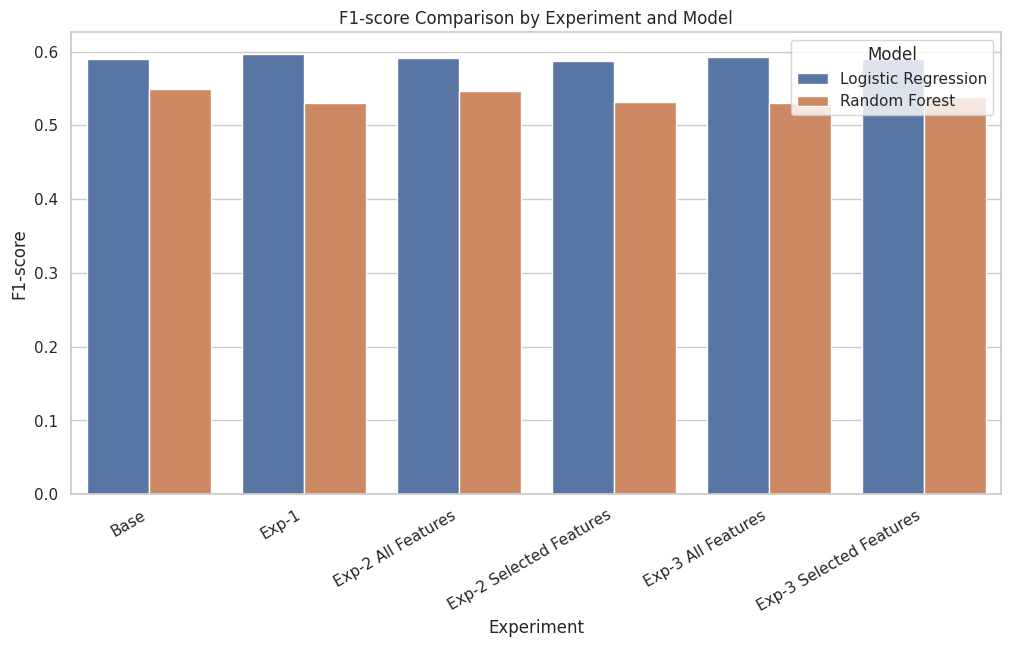

In [101]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df_rounded,
    x="Experiment",
    y="F1-score",
    hue="Model"
)

plt.title("F1-score Comparison by Experiment and Model")
plt.xlabel("Experiment")
plt.ylabel("F1-score")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Model")
plt.show()

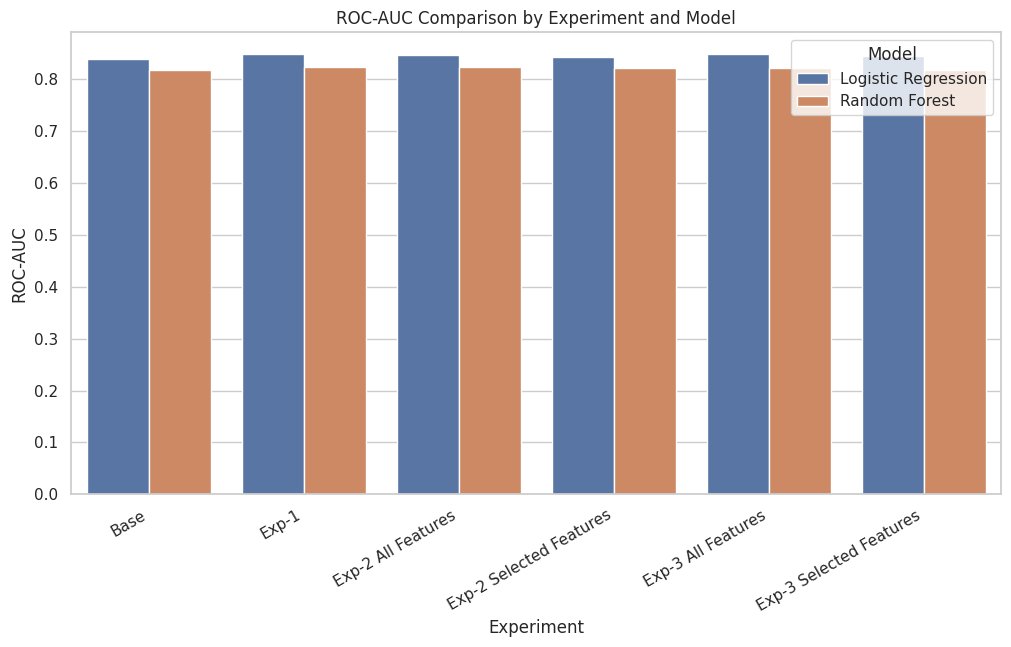

In [102]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df_rounded,
    x="Experiment",
    y="ROC-AUC",
    hue="Model"
)

plt.title("ROC-AUC Comparison by Experiment and Model")
plt.xlabel("Experiment")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Model")
plt.show()

## 5-8. 최적 모델 상세 평가

F1-score를 기준으로 가장 성능이 좋은 실험 조합과 모델을 선택한 뒤, Confusion Matrix와 Classification Report를 통해 상세 성능을 확인한다.

In [103]:
best_result = results_df_rounded.sort_values(by="F1-score", ascending=False).iloc[0]

best_result

,2
Experiment,Exp-1
Model,Logistic Regression
Accuracy,0.807
Precision,0.67
Recall,0.5374
F1-score,0.5964
ROC-AUC,0.848


In [104]:
def plot_confusion_matrix(model, X_train, X_test, y_train, y_test, title):
    """
    Confusion Matrix 시각화 함수
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

In [105]:
def get_dataset_by_experiment(experiment_name):
    """
    실험명에 따라 해당 X_train, X_test, y_train, y_test를 반환하는 함수
    """
    if experiment_name == "Base":
        return X_base_train, X_base_test, y_base_train, y_base_test

    elif experiment_name == "Exp-1":
        return X_train_exp1, X_test_exp1, y_train, y_test

    elif experiment_name == "Exp-2 All Features":
        return X_train_exp2, X_test_exp2, y_train, y_test

    elif experiment_name == "Exp-2 Selected Features":
        return X_train_exp2_selected, X_test_exp2_selected, y_train, y_test

    elif experiment_name == "Exp-3 All Features":
        return X_train_exp3, X_test_exp3, y_train, y_test

    elif experiment_name == "Exp-3 Selected Features":
        return X_train_exp3_selected, X_test_exp3_selected, y_train, y_test

    else:
        raise ValueError("알 수 없는 experiment_name입니다.")

In [106]:
def get_model_by_name(model_name):
    """
    모델명에 따라 모델 객체를 반환하는 함수
    """
    if model_name == "Logistic Regression":
        return LogisticRegression(max_iter=1000, random_state=42)

    elif model_name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )

    else:
        raise ValueError("알 수 없는 model_name입니다.")

최적 실험: Exp-1
최적 모델: Logistic Regression


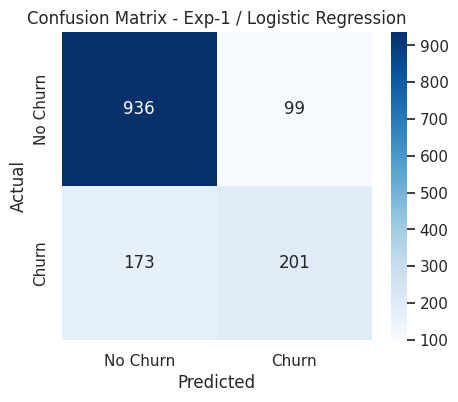

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [107]:
best_experiment = best_result["Experiment"]
best_model_name = best_result["Model"]

best_X_train, best_X_test, best_y_train, best_y_test = get_dataset_by_experiment(best_experiment)
best_model = get_model_by_name(best_model_name)

print("최적 실험:", best_experiment)
print("최적 모델:", best_model_name)

plot_confusion_matrix(
    model=best_model,
    X_train=best_X_train,
    X_test=best_X_test,
    y_train=best_y_train,
    y_test=best_y_test,
    title=f"Confusion Matrix - {best_experiment} / {best_model_name}"
)

## STEP 05 정리

본 단계에서는 Logistic Regression과 Random Forest Classifier를 사용하여 고객 이탈 예측 모델을 학습하고 평가하였다.

성능 평가지표로는 Accuracy, Precision, Recall, F1-score, ROC-AUC를 사용하였다.  
타겟 변수 `Churn`은 다소 불균형한 분포를 가지므로, Accuracy뿐만 아니라 Recall과 F1-score를 함께 고려하는 것이 중요하다.

실험 결과를 통해 Base, Exp-1, Exp-2, Exp-3의 전처리 조합에 따라 모델 성능이 달라지는 것을 확인할 수 있었다.

또한 Exp-2와 Exp-3에서는 Random Forest Feature Importance 기반 Feature Selection을 적용하였고, Feature Selection 전후의 성능을 비교하였다. 이를 통해 변수 선택이 모델 복잡도를 줄이는 동시에 성능에 어떤 영향을 주는지 확인할 수 있었다.

최종적으로 F1-score와 ROC-AUC를 함께 고려하여 가장 적절한 전처리 전략과 모델을 선정한다.